In [1]:
# ============================================================================
# FIG 5: cross-experiment VIB predictions, naive/KNN-based synthetic perturbation
# simulation, and latent-space entropy analysis, for the Z2 (MEKi/WntSeci) and X7
# (LATSi) perturbation experiments, evaluated against a VIB model trained only on
# Exp20 control (B50) data.
# ============================================================================

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import time
import os
import sys
import torch
from skimage import io as imio
import torch.optim as optim
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

sys.path.append('2D_gastruloids_v5')
import fns_plotting_scripts as fns_plot
import fns_NN
import IIF_analysis as IIF

import importlib
importlib.reload(IIF)

<module 'IIF_analysis' from '/Users/idse/repos/signaldecoding/2D_gastruloids_v5/IIF_analysis.py'>

## Data & metadata

In [2]:
# Set up per-experiment configuration and load Exp20 (control reference), Z2, and
# X7 (real perturbation experiments) into ExperimentResults objects. Each exposes:
#   .data       raw per-cell measurements
#   .data_z     z-scored against THIS experiment's own B50 controls -- needed because
#               raw intensity isn't directly comparable across imaging sessions, but
#               z-scored signals are, which is what makes cross-experiment VIB
#               training/prediction meaningful
#   .thresh     per-gene fate-marker positivity threshold, in RAW intensity units,
#               manually calibrated separately for each experiment (see note below)
#   .gene_names, .signal_names, .col/.exp (Colony/Experiment objects)
# Z2 and X7 only measured a 7-gene subset of Exp20's 16 genes.

dataDir = '/Users/idse/data_tmp/signaldecoding/'
coldict_signals = {
    'pSMAD1': '#1F77B4',
    'ncYAP': '#ff7f0e',
    'LEF1': '#3BAF49',
    'BCat': '#F1362B',
    'ncSMAD23': '#9467BD',
    'cytopERK': '#E377C2',
}

# Load all three datasets
config = IIF.ExperimentConfig(
    exp_params = {
        'Z2': (dataDir+'250930_Perturbation6i_MEKi_WntSeci', 'expZ2_data_scaled_bgsub_6_cols_251002.csv',
               {'SOX17_1': 'SOX17', 'TBX6_2': 'TBX6', 'SOX2_2': 'SOX2', 'DAPI_1': 'DAPI'},
               ['B50', 'B50I5', 'B50SB10', 'B50M0p5'],
               {'ISL1': 200, 'TFAP2C': 350, 'SOX17': 200, 'NANOG': 800, 'TBX6': 300, 'TBXT': 175, 'SOX2': 150},
               'expZ2_junk_labels_nans_removed.csv'),
        'X7': (dataDir+'250909_Perturbation6i_LATSi', 'expX7_data_scaled_bgsub_4_cols_250909.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B50T30'],
               {'ISL1': 150, 'TFAP2C': 400, 'SOX17': 200, 'NANOG': 600, 'TBX6': 400, 'TBXT': 175, 'SOX2': 250},
               None),
        '20': (dataDir + '230121_data_BMPdoses', 'exp20_data_bgsub_scaled_250509.csv',
               {'SOX17_1': 'SOX17', 'DAPI_1': 'DAPI'},
               ['B50', 'B200', 'B10'],
               {'ISL1': 500, 'GATA3': 700, 'HAND1': 500, 'CDX2': 600, 'TFAP2C': 600, 'SOX17': 500, 'PRDM1': 650,
                'SNAI1': 300, 'MIXL1': 400, 'EOMES': 200, 'TBXT': 285, 'TBX6': 375, 'OCT4': 500, 'NANOG': 1600,
                'SOX2': 400, 'OTX2': 400},
               None),
    },
    signal_names  = ['pSMAD1', 'ncYAP', 'BCat', 'LEF1', 'ncSMAD23', 'cytopERK'],
    feature_names = ['nucArea', 'nucVolume', 'nucMajorAxis', 'nucMinorAxis',
                     'nucCircularity', 'CircleEdgeDist', 'RadialDist']
)


exp_result_20 = IIF.ExperimentResults('20', config)
exp_result_Z2 = IIF.ExperimentResults('Z2', config)
exp_result_X7 = IIF.ExperimentResults('X7', config)

# markers measured in all three experiments -- the alignment pipeline only makes
# sense for genes common to Exp20, Z2, and X7
common_genes = [g for g in exp_result_Z2.gene_names
                if g in exp_result_20.gene_names and g in exp_result_X7.gene_names]


B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340
B50, Nbins = 544
B50T30, Nbins = 340


In [3]:
# LOAD EXP20'S POSTERIOR-DERIVED THRESHOLDS (computed in fig2n.ipynb, saved to CSV) --
# more principled than exp_result_20.thresh (manual), avoids recomputing
# fit_marker_distributions/fit_posterior_thresholds from scratch here.

threshold_summary_df_20 = pd.read_csv(
    config.exp_params['20'][0] + '/FigS2/marker_threshold_parameters.csv', index_col='marker')
thresh_posterior_20 = threshold_summary_df_20['threshold_posterior'].to_dict()

### Visualize colonies

In [4]:
# Per-channel display percentile ranges used by the multi-condition RGB overlay figure
# below (next cell) -- just image contrast, not related to fate thresholds.

percentiles= {'pSMAD1': [50, 99],
 'YAP': [1, 99.5],
 'BCat': [0.1, 99],
 'LEF1': [1, 99],
 'SMAD23': [1, 99],
 'pERK': [5, 99],
 'pAKT': [10, 99],
 'SMAD2': [1, 99],
 'ISL1': [1, 99],
 'GATA3': [1, 99],
 'HAND1': [1, 99],
 'CDX2': [1, 99],
 'TFAP2C': [1, 97],
 'SOX17': [1, 99],
 'PRDM1': [90, 99.5],
 'SNAI1': [1, 99],
 'MIXL1': [1, 99],
 'EOMES': [1, 99],
 'TBXT': [1, 99],
 'TBX6': [70, 99],
 'OCT4': [1, 99],
 'NANOG': [40, 99],
 'SOX2': [1, 99],
 'SOX2_2': [1, 99],
 'OTX2': [1, 99],
 'DAPI': [1, 99]}

In [5]:
# Determine per-channel display intensity limits (for RGB image rendering only) from
# one representative colony's raw images. Unrelated to the fate-marker thresholds in
# exp_params -- this is purely for how bright each channel looks in the figure panels.
# Percentile pairs come from the percentiles dict above.

expname = 'Z2'
subdataDir = config.exp_params[expname][0]

# determine intensity limits based on control
coli = 2
markers = ['ISL1', 'TFAP2C', 'SOX17', 'NANOG', 'TBX6_2', 'TBXT', 'SOX2_2']
Ilim = dict()

marker_to_percentile_key = {'TBX6_2': 'TBX6'}  # image channel name has a suffix percentiles' key doesn't

for m in markers + ['DAPI']:
    fname = IIF.getImageFilename(coli, m, subdataDir, rdStr='Rd')
    im = imio.imread(fname)
    lo, hi = percentiles[marker_to_percentile_key.get(m, m)]
    Imin, Imax = np.percentile(im[im > 0], [lo, hi])
    Ilim[m] = [Imin, Imax]

loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250925_Perturbation6iExpZ2_set2_120k_ESI17_Rd2_SMAD23_SOX17_LEF1/MIP/stitched_MIP_p0018_w0002_t0000.tif
loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250927_Perturbation6iExpZ2_set2_120k_ESI17_Rd4_TFAP2C_TBX6_pAKT/MIP/stitched_MIP_p0018_w0001_t0000.tif
loading /Users/idse/data_tmp/signaldecoding/250930_Perturbation6i_MEKi_WntSeci/250930_Perturbation6iExpZ2_set2_120k_ESI17_Rd7_SOX2/MIP/stitched_MIP_p0018_w0001_t0000.tif


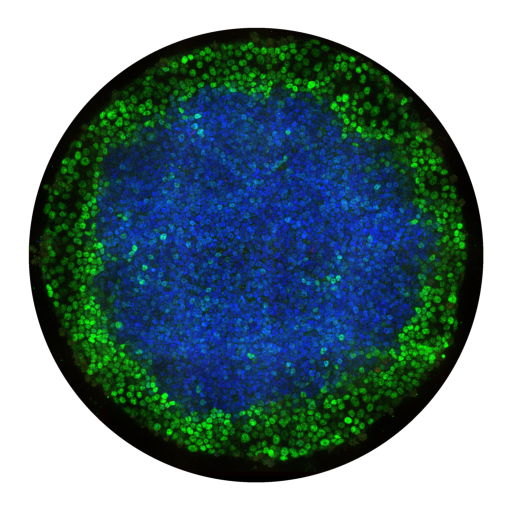

In [6]:
# Render a pseudocolored RGB overlay of raw microscopy images for one Z2 colony, for
# visual inspection / figure panels.

# example channel overlay
colID = 19
#stains = signal_names_simplified 
stains = ['SOX17', 'TFAP2C', 'SOX2_2']
overlay_markers = [None]
for ov in overlay_markers:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    overlay_marker = ov
    
    RGBbase, image_meta = IIF.makeRGBbase(exp_result_Z2.col, colID, stains, subdataDir, outer_margin=100, crop_margin= 140, center_x_margin = 0, center_y_margin = -0, 
                                Ilim = Ilim, rdStr='Rd')
    
    ax.imshow(RGBbase);
    ax.axis('off');

    import imageio
    #imageio.imwrite(dataDir + f'/B50M0p5_SOX17_TFAP2C_SOX2.png', RGBoverlay)

## Discretization

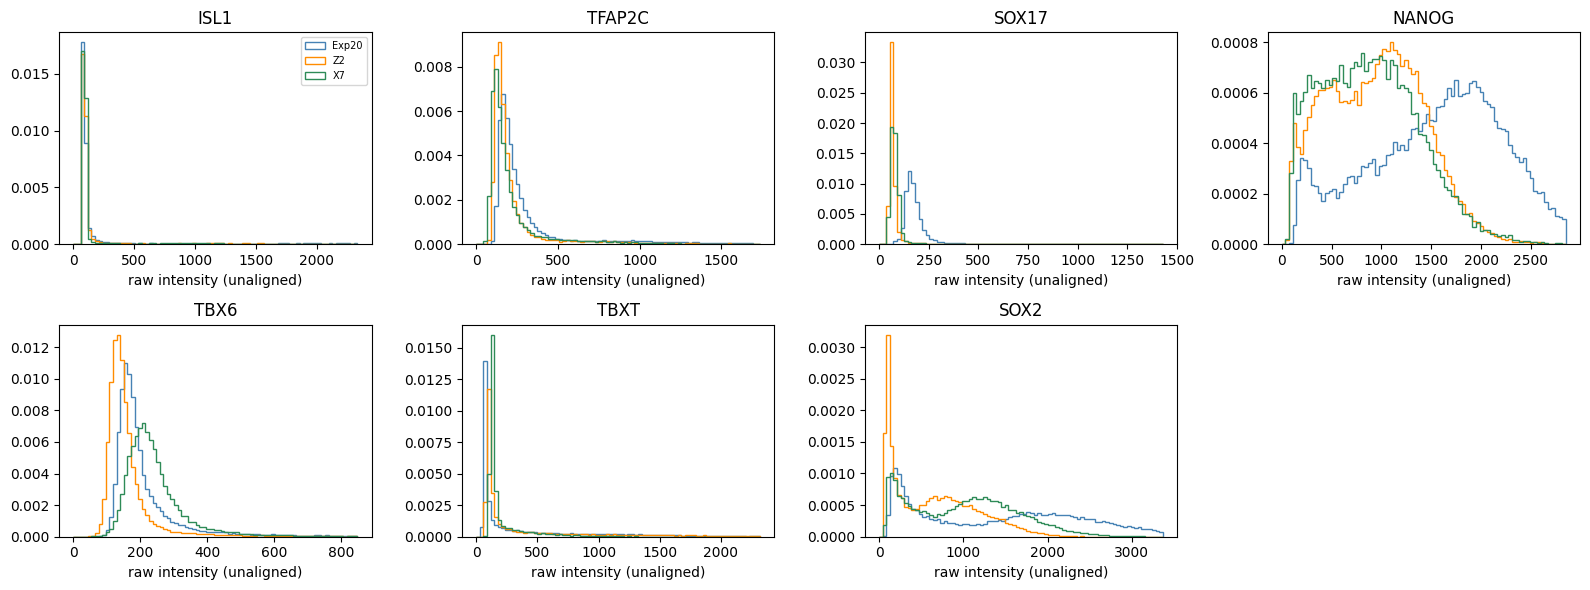

In [8]:
# plot raw (unaligned) distributions

def get_b50(exp_result, marker):
    """Raw (unaligned) intensity values for one marker, B50 condition only, NaNs dropped."""
    data_cond = exp_result.data[exp_result.data['condition'] == 'B50']
    values = data_cond[marker].to_numpy()
    return values[~np.isnan(values)]

ncols = 4
nrows = int(np.ceil(len(common_genes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, marker in enumerate(common_genes):
    ax = axes[i]
    v20, vZ2, vX7 = get_b50(exp_result_20, marker), get_b50(exp_result_Z2, marker), get_b50(exp_result_X7, marker)
    hi = np.percentile(np.concatenate([v20, vZ2, vX7]), 99)
    bins = np.linspace(0, hi, 80)

    ax.hist(v20, bins=bins, density=True, histtype='step', color='steelblue', label='Exp20')
    ax.hist(vZ2, bins=bins, density=True, histtype='step', color='darkorange', label='Z2')
    ax.hist(vX7, bins=bins, density=True, histtype='step', color='seagreen', label='X7')

    ax.set_title(marker)
    ax.set_xlabel('raw intensity (unaligned)')
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(common_genes), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# FIT GENE ALIGNMENT: peak-anchored shift + log-density-matched scale, mapping Z2/X7's
# raw gene units onto Exp20's (see IIF.fit_gene_alignment / IIF.optimize_intensity_scale
# for the method).

align_params = {}
for exp_name, exp_result in [('Z2', exp_result_Z2), ('X7', exp_result_X7)]:
    for marker, params in IIF.fit_gene_alignment(exp_result.data, exp_result_20.data, common_genes).items():
        align_params[(exp_name, marker)] = params

def apply_signal_alignment(exp_result, align_params_for_exp, columns):
    """Apply a fitted {column: (scale, shift)} mapping to exp_result's full dataframe (every
    condition, not just B50) and rebuild Colony/Experiment objects from the result. Generic
    over any list of column names -- gene markers or signaling channels."""
    data_aligned = IIF.apply_alignment(exp_result.data, align_params_for_exp, columns)
    return IIF.create_experiment(data_aligned, exp_result.meta, exp_result.feature_names)

# Exp20 itself is the reference -- build its (unmodified) Experiment object the same way,
# just without applying any transform, so it plots alongside the aligned ones below.
col_20, exp_20 = IIF.create_experiment(exp_result_20.data, exp_result_20.meta, exp_result_20.feature_names)


B50, Nbins = 609
B200, Nbins = 576
B10, Nbins = 503


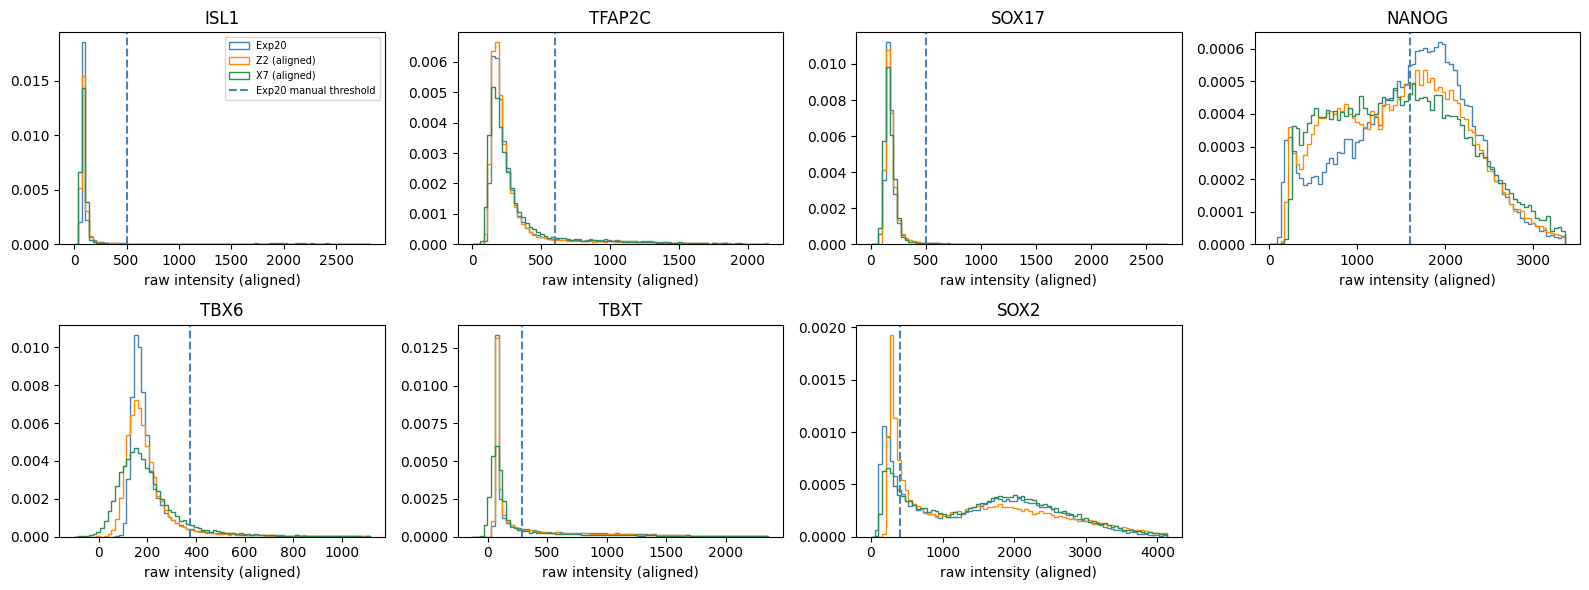

In [ ]:
# Plot aligned linear intensity distributions

ncols = 4
nrows = int(np.ceil(len(common_genes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, marker in enumerate(common_genes):
    ax = axes[i]
    v20 = get_b50(exp_result_20, marker)
    scale_Z2, shift_Z2 = align_params[('Z2', marker)]
    scale_X7, shift_X7 = align_params[('X7', marker)]
    vZ2a = get_b50(exp_result_Z2, marker) * scale_Z2 + shift_Z2
    vX7a = get_b50(exp_result_X7, marker) * scale_X7 + shift_X7

    hi = np.percentile(np.concatenate([v20, vZ2a, vX7a]), 99)
    lo = min(0, vZ2a.min(), vX7a.min())
    bins = np.linspace(lo, hi, 80)

    ax.hist(v20, bins=bins, density=True, histtype='step', color='steelblue', label='Exp20')
    ax.hist(vZ2a, bins=bins, density=True, histtype='step', color='darkorange', label='Z2 (aligned)')
    ax.hist(vX7a, bins=bins, density=True, histtype='step', color='seagreen', label='X7 (aligned)')
    # placeholder: manual threshold for now -- swap for the fig2n.ipynb-computed automated
    # threshold once that gets loaded in here
    ax.axvline(exp_result_20.thresh[marker], color='steelblue', linestyle='--', label='Exp20 manual threshold')

    ax.set_title(marker)
    ax.set_xlabel('raw intensity (aligned)')
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(common_genes), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


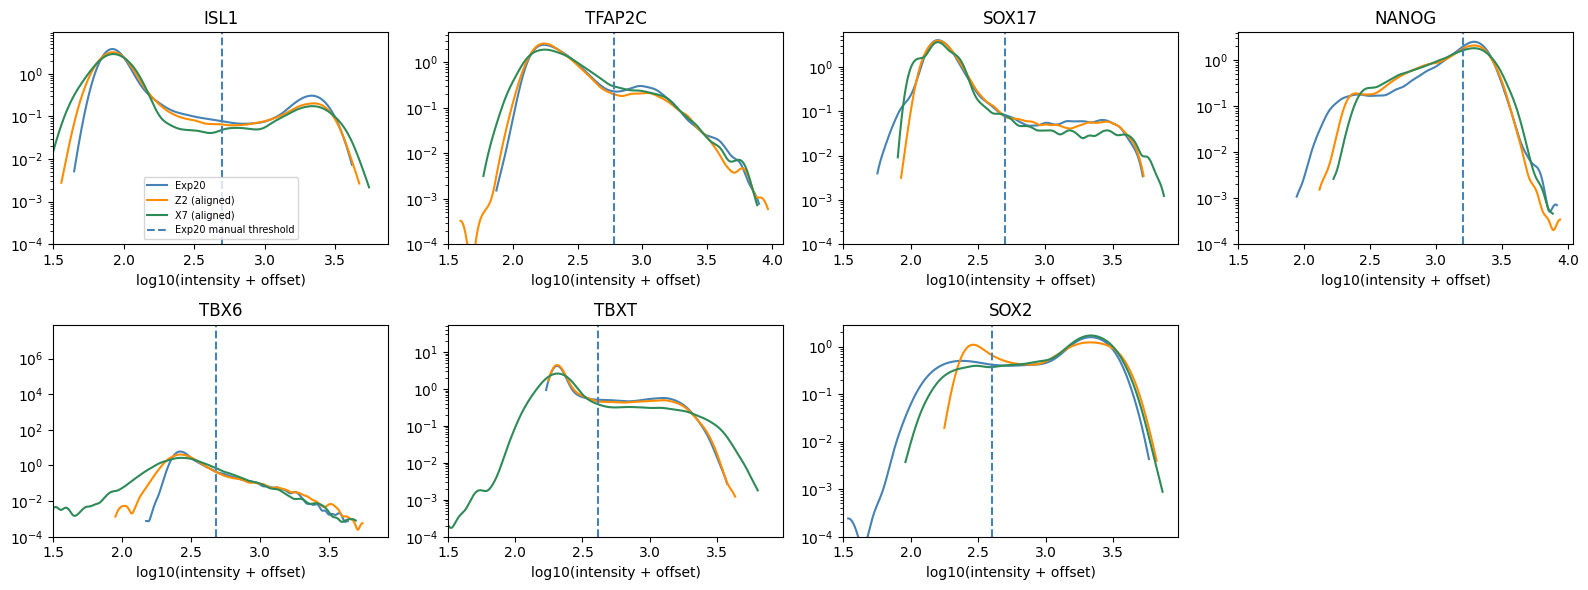

In [ ]:
# STEP 4: transform the aligned linear data back to log scale for viewing
def shared_offset_for_marker(marker):
    v20 = get_b50(exp_result_20, marker)
    scale_Z2, shift_Z2 = align_params[('Z2', marker)]
    scale_X7, shift_X7 = align_params[('X7', marker)]
    vZ2a = get_b50(exp_result_Z2, marker) * scale_Z2 + shift_Z2
    vX7a = get_b50(exp_result_X7, marker) * scale_X7 + shift_X7
    global_min = min(v20.min(), vZ2a.min(), vX7a.min())
    return 0.0 if global_min > 0 else (1.0 - global_min)

ncols = 4
nrows = int(np.ceil(len(common_genes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, marker in enumerate(common_genes):
    ax = axes[i]
    offset = shared_offset_for_marker(marker)

    v20 = get_b50(exp_result_20, marker)
    scale_Z2, shift_Z2 = align_params[('Z2', marker)]
    scale_X7, shift_X7 = align_params[('X7', marker)]
    vZ2a = get_b50(exp_result_Z2, marker) * scale_Z2 + shift_Z2
    vX7a = get_b50(exp_result_X7, marker) * scale_X7 + shift_X7

    log_20 = np.log10(v20 + offset)
    log_Z2 = np.log10(vZ2a + offset)
    log_X7 = np.log10(vX7a + offset)

    for label, log_vals, color in [('Exp20', log_20, 'steelblue'),
                                     ('Z2 (aligned)', log_Z2, 'darkorange'),
                                     ('X7 (aligned)', log_X7, 'seagreen')]:
        _, all_modes, grid, density = IIF.background_mode(log_vals)
        ax.plot(grid, density, color=color, label=label)

    # placeholder: manual threshold for now -- swap for the fig2n.ipynb-computed automated
    # threshold once that gets loaded in here
    ax.axvline(np.log10(exp_result_20.thresh[marker] + offset), color='steelblue', linestyle='--', label='Exp20 manual threshold')

    ax.set_yscale('log')
    ax.set_xlim(left=1.5)
    ax.set_ylim(bottom=1e-4)
    ax.set_title(marker)
    ax.set_xlabel('log10(intensity + offset)')
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(common_genes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
os.makedirs('Fig5', exist_ok=True)
plt.savefig('Fig5/exp20_vs_Z2_vs_X7_distribution_shape_linear_aligned.png', dpi=150)
plt.show()


B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340


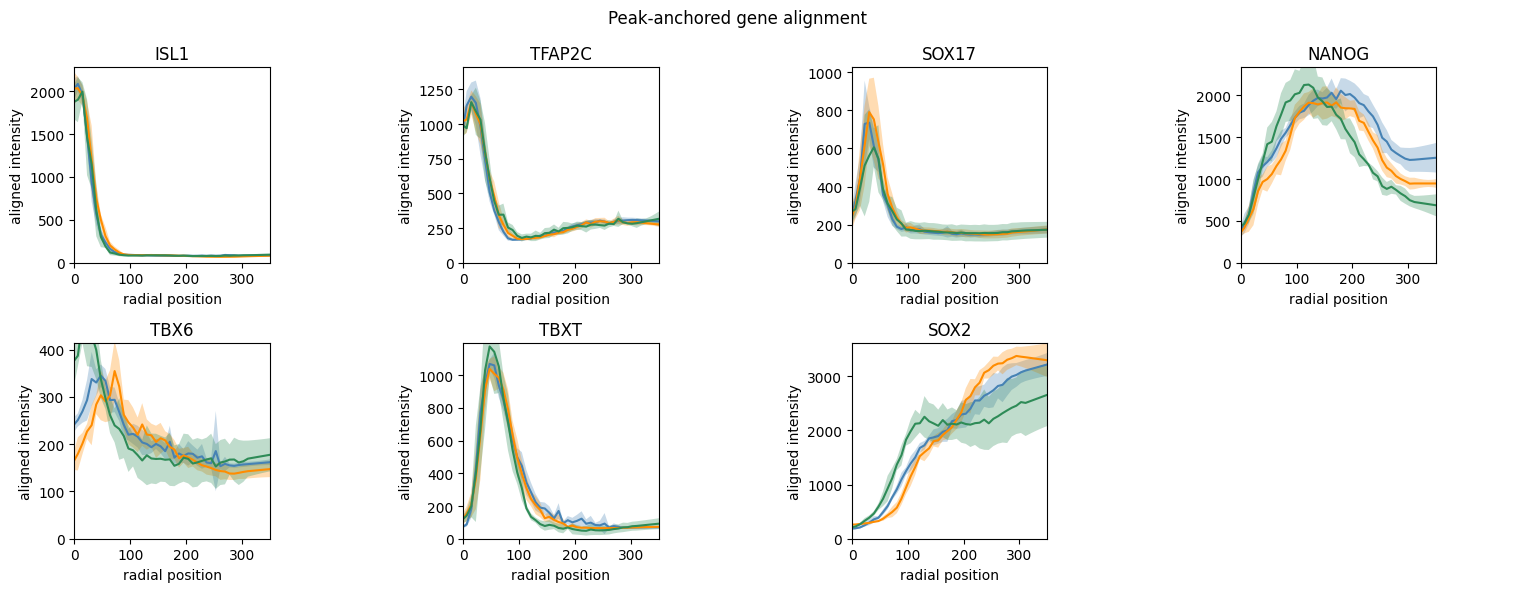

In [ ]:
# APPLY GENE ALIGNMENT, REBUILD EXPERIMENT OBJECTS, PLOT RADIAL PROFILES

align_Z2_gene = {m: align_params[('Z2', m)] for m in common_genes}
align_X7_gene = {m: align_params[('X7', m)] for m in common_genes}

col_aligned_Z2_gene, exp_aligned_Z2_gene = apply_signal_alignment(exp_result_Z2, align_Z2_gene, common_genes)
col_aligned_X7_gene, exp_aligned_X7_gene = apply_signal_alignment(exp_result_X7, align_X7_gene, common_genes)

ncols = 4
nrows = int(np.ceil(len(common_genes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, marker in enumerate(common_genes):
    ax = axes[i]
    exp_20.plotRadialProfiles(marker, 'B50', mode='colonies', sigma=1, color='steelblue', ax=ax)
    exp_aligned_Z2_gene.plotRadialProfiles(marker, 'B50', mode='colonies', sigma=1, color='darkorange', ax=ax)
    exp_aligned_X7_gene.plotRadialProfiles(marker, 'B50', mode='colonies', sigma=1, color='seagreen', ax=ax)

    ax.set_title(marker)
    ax.set_xlabel('radial position')
    ax.set_ylabel('aligned intensity')

for j in range(len(common_genes), len(axes)):
    axes[j].axis('off')
plt.suptitle('Peak-anchored gene alignment')
plt.tight_layout()
plt.show()


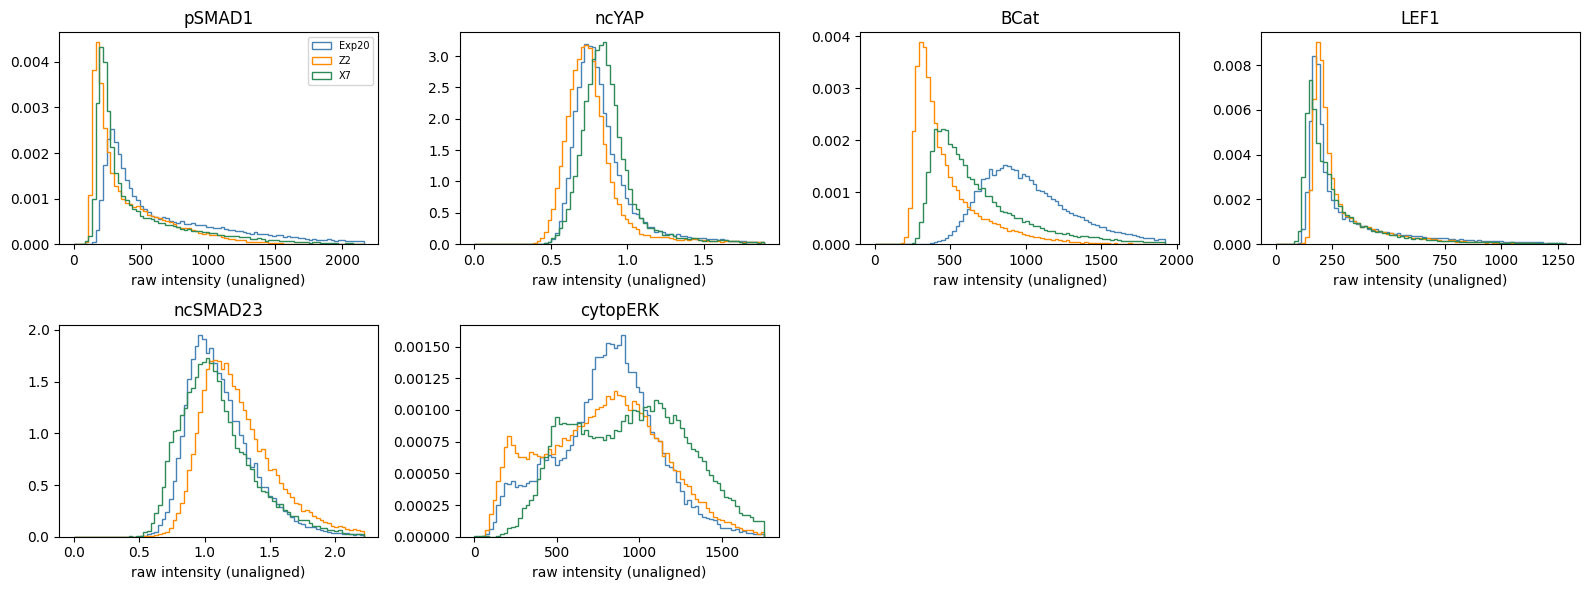

In [ ]:
# common_signals: input signaling channels measured in all three experiments
# (distinct from common_genes -- these are exp_result.signal_names, not gene_names)
common_signals = [s for s in exp_result_Z2.signal_names
                   if s in exp_result_20.signal_names and s in exp_result_X7.signal_names]

# PLOT: raw signaling intensity distributions, unaligned
# Reuses get_b50 as-is -- it just pulls a named column from the B50 condition,
# works the same whether that column is a gene marker or a signaling channel.
ncols = 4
nrows = int(np.ceil(len(common_signals) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, signal in enumerate(common_signals):
    ax = axes[i]
    v20, vZ2, vX7 = get_b50(exp_result_20, signal), get_b50(exp_result_Z2, signal), get_b50(exp_result_X7, signal)
    hi = np.percentile(np.concatenate([v20, vZ2, vX7]), 99)
    bins = np.linspace(0, hi, 80)

    ax.hist(v20, bins=bins, density=True, histtype='step', color='steelblue', label='Exp20')
    ax.hist(vZ2, bins=bins, density=True, histtype='step', color='darkorange', label='Z2')
    ax.hist(vX7, bins=bins, density=True, histtype='step', color='seagreen', label='X7')

    ax.set_title(signal)
    ax.set_xlabel('raw intensity (unaligned)')
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(common_signals), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# FIT SIGNAL ALIGNMENT: z-score against own B50, rescaled onto Exp20's -- see
# IIF.fit_zscore_alignment for the method.

align_Z2_signal_zscore = IIF.fit_zscore_alignment(exp_result_Z2.data, exp_result_20.data, common_signals)
align_X7_signal_zscore = IIF.fit_zscore_alignment(exp_result_X7.data, exp_result_20.data, common_signals)

col_aligned_Z2_zscore, exp_aligned_Z2_zscore = apply_signal_alignment(exp_result_Z2, align_Z2_signal_zscore, common_signals)
col_aligned_X7_zscore, exp_aligned_X7_zscore = apply_signal_alignment(exp_result_X7, align_X7_signal_zscore, common_signals)


B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340


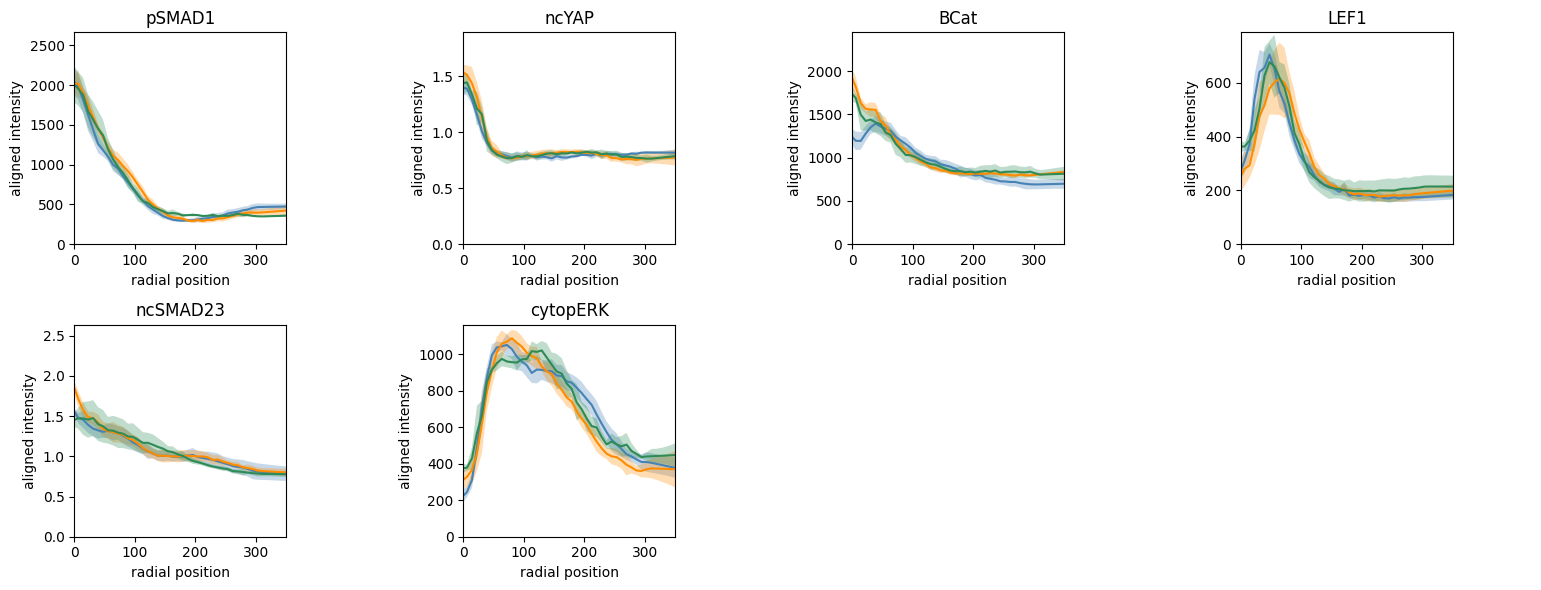

In [ ]:
# PLOT: radial signaling profiles, Exp20 vs Z2/X7 after alignment, B50 condition
# One subplot per signal, all three experiments overlaid -- checks whether the
# SPATIAL (radial position) trend agrees after alignment, not just the overall
# (position-agnostic) intensity distribution matched above.

ncols = 4
nrows = int(np.ceil(len(common_signals) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = np.atleast_1d(axes).ravel()

for i, signal in enumerate(common_signals):
    ax = axes[i]
    exp_20.plotRadialProfiles(signal, 'B50', mode='colonies', sigma=1, color='steelblue', ax=ax)
    exp_aligned_Z2_zscore.plotRadialProfiles(signal, 'B50', mode='colonies', sigma=1, color='darkorange', ax=ax)
    exp_aligned_X7_zscore.plotRadialProfiles(signal, 'B50', mode='colonies', sigma=1, color='seagreen', ax=ax)

    ax.set_title(signal)
    ax.set_xlabel('radial position')
    ax.set_ylabel('aligned intensity')

for j in range(len(common_signals), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


## Compare conditions

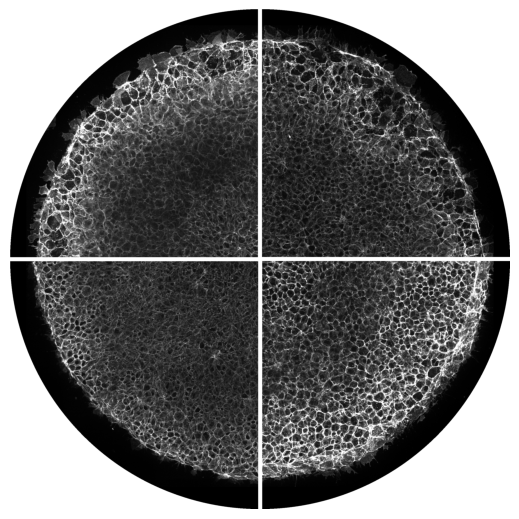

In [9]:
# Build side-by-side RGB overlays comparing colonies from different conditions/
# experiments (BCat channel), for a summary figure panel.

# Plot four-way colony images
overlay_configs = [
    # (col_dict,  col_id, ref_col, center_x_margin, center_y_margin, data_dir)
    (exp_result_Z2.col,  19, 2,  30,   -80,  config.exp_params['Z2'][0]),
    (exp_result_X7.col,   8, 2,   0,    0,   config.exp_params['X7'][0]),
    (exp_result_Z2.col,   8, 2, -30,   40,   config.exp_params['Z2'][0]),
    (exp_result_Z2.col,   2, 2,   0,  -20,   config.exp_params['Z2'][0]),
]

# Unpack for IIF function
cols              = [c[0] for c in overlay_configs]
colis             = [c[1] for c in overlay_configs]
ref_cols          = [c[2] for c in overlay_configs]
center_x_margins  = [c[3] for c in overlay_configs]
center_y_margins  = [c[4] for c in overlay_configs]
dataDirs = [c[5] for c in overlay_configs]


import imageio
import importlib
importlib.reload(IIF)

for marker in ['BCat']:
    RGBoverlay = IIF.makeRGBoverlay_colisectors(
        cols=cols, colis=colis, marker=marker,
        dataDirs=dataDirs,
        crop_margin=70, reference_cols=ref_cols,
        center_x_margins=center_x_margins,
        center_y_margins=center_y_margins,
        percentiles=percentiles,
        outer_margin=80
    )
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(RGBoverlay)
    ax.axis('off')
    ax.set_aspect('equal')
    plt.tight_layout(pad=0)
    
    imageio.imwrite(
        dataDir+f'/Fig5/four_cond_overview_{marker}_MIPs.png',
        RGBoverlay
    )
    plt.show()

In [10]:
# Rescale each experiment's radial signaling profiles so the B50 control's own
# min/max map to 0/1. Puts different experiments/conditions on a comparable relative
# scale for the profile plots below, without touching the raw data used elsewhere.

sigs_to_plot = config.signal_names
# Normalize and create experiments
data_norm_Z2, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_Z2.data_z, exp_result_Z2.exp_z, sigs_to_plot
)
data_norm_X7, _, _ = IIF.normalize_to_ctrl_profile(
    exp_result_X7.data_z, exp_result_X7.exp_z, sigs_to_plot
)

col_norm_Z2, exp_norm_Z2 = IIF.create_experiment(data_norm_Z2, exp_result_Z2.meta, exp_result_Z2.feature_names)
col_norm_X7, exp_norm_X7 = IIF.create_experiment(data_norm_X7, exp_result_X7.meta, exp_result_X7.feature_names)

plot_configs_norm = [
    (exp_norm_Z2, 'B50',     'Z2 ctrl'),
    (exp_norm_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_norm_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_norm_X7, 'B50T30',  'X7 TRULI'),
]

B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 544
B50T30, Nbins = 340


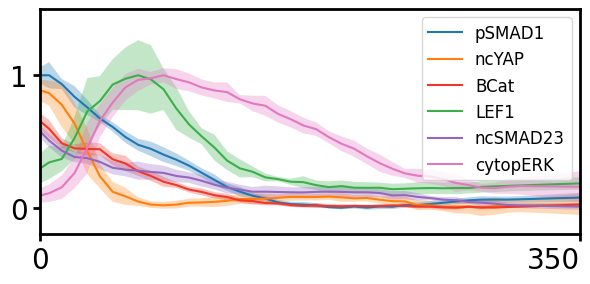

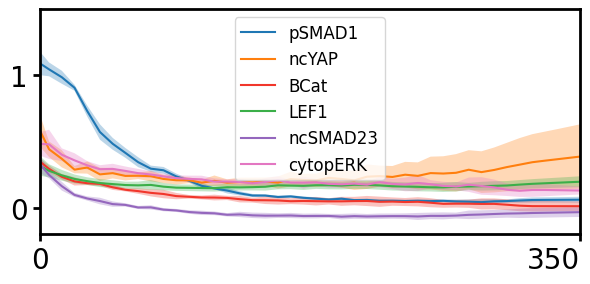

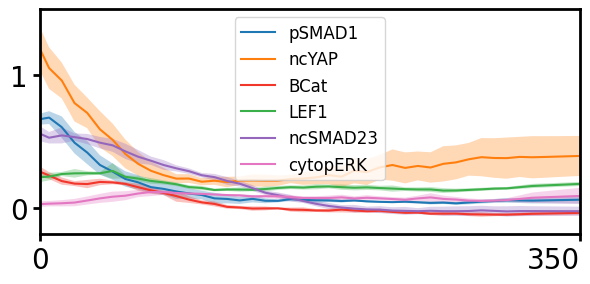

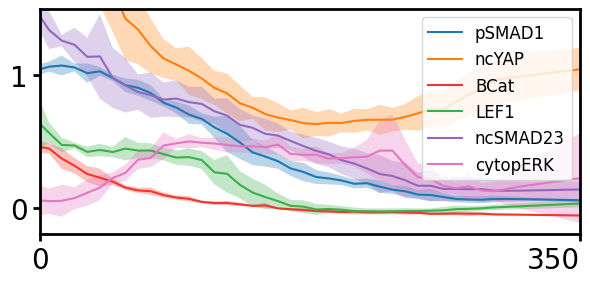

In [11]:
# Plot radial (colony-center-to-edge) profiles of each of the 6 input signals, for the
# B50 control and each perturbation condition, using the profile-normalized data from
# the previous cell.

# Plot signaling profiles
fs = 16
fs_ticks = 20
sw = 2

for legend in [True]:
    suffix = '_legend' if legend else ''
    
    for exp_norm, cond, label in plot_configs_norm:
        
        fig, ax = plt.subplots(figsize=(6, 3))  # match fate_histogram figsize
        
        handles = []
        for s in sigs_to_plot:
            h = exp_norm.plotRadialProfiles(
                s, cond, mode='colonies', sigma=1,
                color=coldict_signals[s], ax=ax
            )
            handles.append(h)
        
        ax.set_xlabel('', fontsize=fs)
        ax.set_ylabel('', fontsize=fs)
        ax.set_ylim(-0.2, 1.5)
        
        ax.set_xticks([0, 350])
        ax.set_xticklabels(['0', '350'], fontsize=fs_ticks)
        
        # Center '0' under its tick, right-align '350' under its tick
        ax.xaxis.get_major_ticks()[0].label1.set_horizontalalignment('center')
        ax.xaxis.get_major_ticks()[1].label1.set_horizontalalignment('right')
        ax.set_box_aspect(1/2.4)  # match fate_histogram aspect ratio
        
        for spine in ax.spines.values():
            spine.set_linewidth(sw)
        
        ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
        ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
        
        y_min, y_max = ax.get_ylim()
        ax.set_yticks(np.arange(int(np.ceil(y_min)), int(np.floor(y_max)) + 1, 1))
        
        if legend:
            ax.legend(handles=handles, labels=sigs_to_plot, fontsize=12)
        
        plt.tight_layout()
        plt.savefig(
            dataDir+f'Fig5/signaling_profiles_{label}{suffix}.png', dpi=150, bbox_inches='tight'
        )
        plt.show()
        plt.close()

## Cross-experiment prediction

In [26]:
def display_predicted_fate_calls(pred_source, suffix_prefix):
    """Scatter/histogram fate-call display for a predicted-fate dict keyed like avg_preds
    (per (exp_name, cond)), looped over perturb_panels. Reuses USE_TRANSFERRED_THRESHOLD,
    align_to_20, _ThreshWrapper, thresh_posterior_20, common_genes, ms from earlier cells."""
    for exp_result, exp_name, cond, colID, label in perturb_panels:
        pred_cond = pred_source[(exp_name, cond)]

        if USE_TRANSFERRED_THRESHOLD:
            pred_cond = IIF.apply_alignment(pred_cond, align_to_20[exp_name], common_genes)
            thresh = thresh_posterior_20
            thresh_obj = _ThreshWrapper(thresh)
            suffix = 'exp20transferred'
        else:
            thresh = exp_result.thresh
            thresh_obj = exp_result
            suffix = 'manual'

        meta_single_cond = copy.deepcopy(exp_result.meta)
        meta_single_cond.conditions = [cond]
        col_pred_single, _ = IIF.create_experiment(pred_cond, meta_single_cond, exp_result.feature_names)
        colony = col_pred_single[colID]

        filename = dataDir + f'/Fig5/colony_scatter_{label}_{suffix_prefix}_{suffix}.png'
        hist_filename = dataDir + f'/Fig5/hist_{label}_{suffix_prefix}_{suffix}.png'

        fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
        colony.scatter_fates(ms=ms, ax=ax, legend=False, thresh=thresh)
        #ax.set_title(f'{label}: {suffix_prefix} (colony {colID}, {suffix})')
        plt.savefig(filename, bbox_inches='tight')

        IIF.fate_histogram(pred_cond, thresh_obj)
        plt.savefig(hist_filename, bbox_inches='tight')


def show_cross_prediction_performance(exp_result, exp_name, cond, avg_preds, label):
    """Per-fold (colony) marker-level and fate-category performance (f1_rand, f1,
    balanced_accuracy shown together) for one perturbation condition's cross-experiment
    prediction. Both the prediction and the measured ground truth are transferred into
    Exp20's units via align_to_20 and scored against thresh_posterior_20 -- matching the
    comparison basis already established for this notebook. Call once per prediction
    variant (e.g. once after a with-BCat rerun, once after a without-BCat rerun) and
    compare the resulting plots side by side. Prints an identifying line before each plot
    (condition, metric type, output file) so runs are distinguishable in the notebook
    output -- not part of the figure itself, so it won't end up in a saved PNG."""
    data_cond = exp_result.data[exp_result.data['condition'] == cond]
    data_cond_in20units = IIF.apply_alignment(data_cond, align_to_20[exp_name], common_genes)
    colonies = data_cond_in20units['Colony'].to_numpy()

    pred_in20units = IIF.apply_alignment(avg_preds[(exp_name, cond)], align_to_20[exp_name], common_genes)

    # --- Marker-level performance
    df_marker = IIF.compute_marker_performance_perfold(
        data_cond_in20units, pred_in20units, colonies, common_genes, thresh_posterior_20)
    df_marker = IIF.add_group_avg(df_marker, ['f1', 'balanced_accuracy'], group_col='gene')
    marker_fname = dataDir + f'/Fig5/perfold_marker_{label}.png'
    print(f'{label}: marker-level performance -> {marker_fname}')
    IIF.plot_category_performance_perfold(
        df_marker, common_genes + ['marker_avg'], marker_fname, group_col='gene')

    # --- Fate-category performance
    true_fates, fate_names_raw = IIF.return_fates(data_cond_in20units, thresh=thresh_posterior_20)
    fate_names_list = [f for f in fate_names_raw if f != 'other']
    pred_fates, _ = IIF.return_fates(pred_in20units, thresh=thresh_posterior_20)

    df_fate = pd.DataFrame(IIF.compute_category_performance_perfold(
        true_fates, pred_fates, colonies, fate_names_list, aggregate_name='all fates'))
    fate_fname = dataDir + f'/Fig5/perfold_fate_{label}.png'
    print(f'{label}: fate-category performance -> {fate_fname}')
    IIF.plot_category_performance_perfold(
        df_fate, fate_names_list + ['all fates'], fate_fname, group_col='category')

    return df_marker, df_fate



B50T30, Nbins = 340
B50I5, Nbins = 661
B50M0p5, Nbins = 518


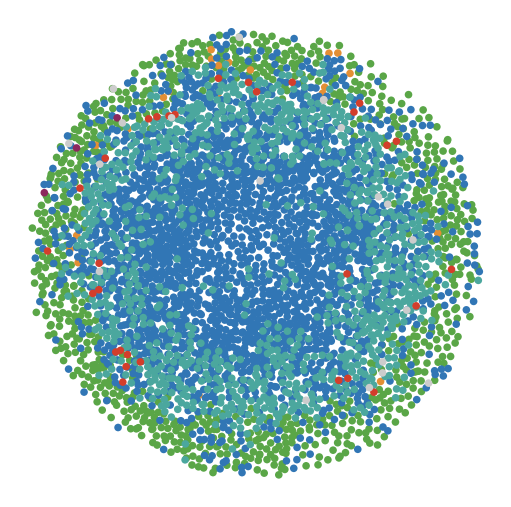

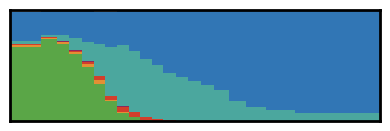

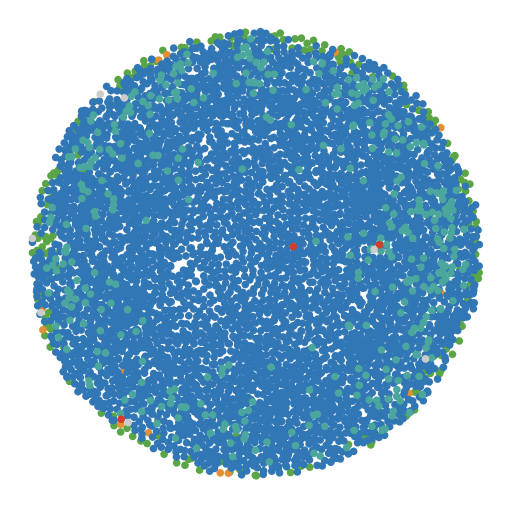

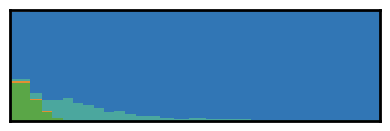

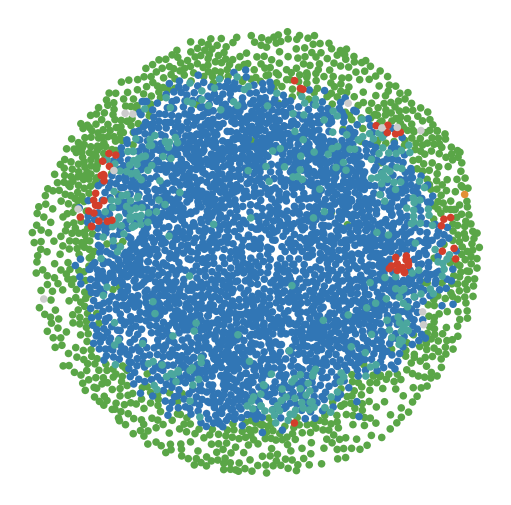

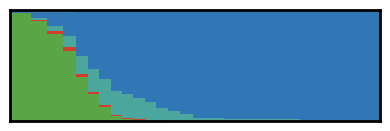

In [23]:
# Show the ACTUAL measured colony fate calls for all three real perturbation conditions.
# TOGGLE: USE_TRANSFERRED_THRESHOLD=True (default) aligns each experiment's data into
# Exp20's units and scores it with Exp20's posterior threshold (thresh_posterior_20) --
# the preferred view now, since every experiment lands on the same, better-calibrated
# threshold. Set to False to go back to each experiment's own native units + manual
# threshold, for comparison/sanity checks.

USE_TRANSFERRED_THRESHOLD = True
ms = 30

align_Z2_to_20 = IIF.fit_gene_alignment(exp_result_Z2.data, exp_result_20.data, common_genes)
align_X7_to_20 = IIF.fit_gene_alignment(exp_result_X7.data, exp_result_20.data, common_genes)

class _ThreshWrapper:
    def __init__(self, thresh):
        self.thresh = thresh

align_to_20 = {
    'X7': align_X7_to_20,
    'Z2': align_Z2_to_20,  
}

perturb_panels = [
    (exp_result_X7, 'X7', 'B50T30', 8, 'TRULI'),
    (exp_result_Z2, 'Z2', 'B50I5', 8, 'IWP2'),
    (exp_result_Z2, 'Z2', 'B50M0p5', 19, 'MEKi'),
]

for exp_result, exp_name, cond, colID, label in perturb_panels:
    data_cond = exp_result.data[exp_result.data['condition'] == cond]

    if USE_TRANSFERRED_THRESHOLD:
        data_cond = IIF.apply_alignment(data_cond, align_to_20[exp_name], common_genes)
        meta_single_cond = copy.deepcopy(exp_result.meta)
        meta_single_cond.conditions = [cond]
        col_single, _ = IIF.create_experiment(data_cond, meta_single_cond, exp_result.feature_names)
        colony = col_single[colID]
        thresh = thresh_posterior_20
        thresh_obj = _ThreshWrapper(thresh)
        suffix = 'exp20transferred'
    else:
        colony = exp_result.col[colID]
        thresh = exp_result.thresh
        thresh_obj = exp_result
        suffix = 'manual'

    filename = dataDir + f'/Fig5/colony_scatter_{label}_exp_{suffix}.png'
    hist_filename = dataDir + f'/Fig5/hist_{label}_exp_{suffix}.png'

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
    colony.scatter_fates(ms=ms, ax=ax, legend=False, thresh=thresh)
    #ax.set_title(f'{label}: measured (colony {colID}, {suffix})')
    plt.savefig(filename)

    IIF.fate_histogram(data_cond, thresh_obj)
    plt.savefig(hist_filename)


In [61]:
# THE MAIN CROSS-EXPERIMENT PREDICTION: train VIB on Exp20's own B50 control data
# only, then predict fate-marker expression for the REAL (not synthetic) Z2 and X7
# perturbation conditions, using signals actually measured in those experiments.
# Tests whether a model that has only ever seen unperturbed control data can still
# predict how real drug perturbations change fate, purely from the six input signals.
# Restricted to common_gene_names since Z2/X7 only measured a 7-gene subset of
# Exp20's 16 genes.

importlib.reload(IIF);

exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}
hyperparam = {'HIDDEN_DIM':32, 'N_LAYERS':2, 'LATENT_DIM': 2}

train_configs = [('20', 'B50')]
test_configs  = [('X7', 'B50T30'), ('Z2', 'B50I5'), ('Z2', 'B50M0p5')]

avg_preds, predictions = IIF.run_vib_joint_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names=[s for s in config.signal_names if s not in ['BCat']], # EXCLUDING BCAT HERE
    gene_names=common_genes,
    reference_exp='20',
    hyperparam=hyperparam,
    N_run=3,
    out_dir=dataDir + '/VIB_across',
    out_prefix='vib_meas_exp20_space_nobcat',
    recompute=True,
    label='exp20-only training')

[exp20-only training] aligned Z2 -> 20
[exp20-only training] aligned X7 -> 20
[exp20-only training] Run 0/3
[exp20-only training]   fold 0/6
[exp20-only training]   fold 1/6
[exp20-only training]   fold 2/6
[exp20-only training]   fold 3/6
[exp20-only training]   fold 4/6
[exp20-only training]   fold 5/6
[exp20-only training (joint, run 0)] Run 0/1
[exp20-only training (joint, run 0)]   training on 30431 cells
[exp20-only training (joint, run 0)]   predicting 44213 cells
[exp20-only training (joint, run 0)] Elapsed time: 3.3 seconds
[exp20-only training (joint, run 0)] Run 0/1
[exp20-only training (joint, run 0)]   training on 30431 cells
[exp20-only training (joint, run 0)]   predicting 132522 cells
[exp20-only training (joint, run 0)] Elapsed time: 4.1 seconds
[exp20-only training] Elapsed time: 25.4 seconds
[exp20-only training] Run 1/3
[exp20-only training]   fold 0/6
[exp20-only training]   fold 1/6
[exp20-only training]   fold 2/6
[exp20-only training]   fold 3/6
[exp20-only trai

In [62]:
# Wrap the raw cross-experiment predictions back into Colony/Experiment objects
# (matching each source experiment's own metadata) so they can be plotted the same
# way as measured data.

# Reconstruct exp and col objects from avg_preds

exp_objects = {}
col_objects = {}

for (exp_name, cond), avg_pred in avg_preds.items():
    exp_res = exp_results_list[exp_name]
    
    # Create a copy of meta with the correct condition
    meta = copy.deepcopy(exp_res.meta)
    meta.conditions = [cond]
    
    # Create colony and experiment objects
    col, exp = IIF.create_experiment(avg_pred, meta, exp_res.feature_names)
    
    col_objects[(exp_name, cond)] = col
    exp_objects[(exp_name, cond)] = exp
    
    print(f"  {exp_name} {cond}: {len(col)} colonies, {len(avg_pred)} cells")

B50, Nbins = 609
  20 B50: 6 colonies, 30431 cells
B50T30, Nbins = 340
  X7 B50T30: 4 colonies, 17007 cells
B50I5, Nbins = 661
  Z2 B50I5: 6 colonies, 33047 cells
B50M0p5, Nbins = 518
  Z2 B50M0p5: 6 colonies, 25892 cells


B50T30, Nbins = 340
B50I5, Nbins = 661
B50M0p5, Nbins = 518


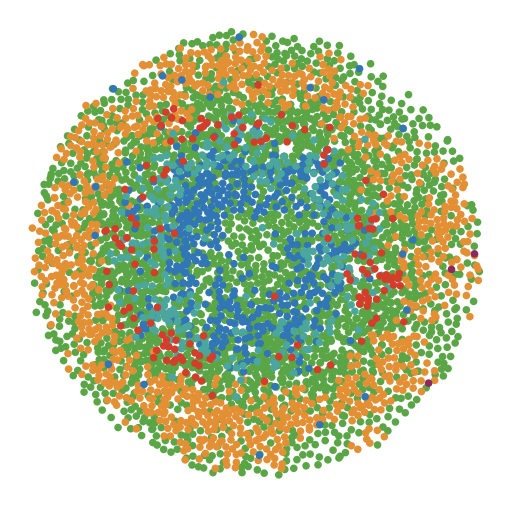

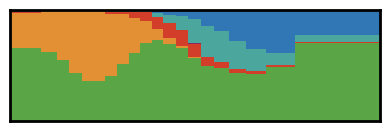

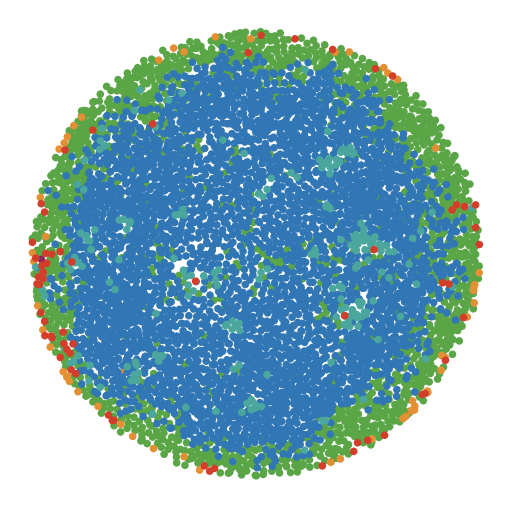

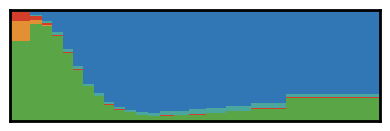

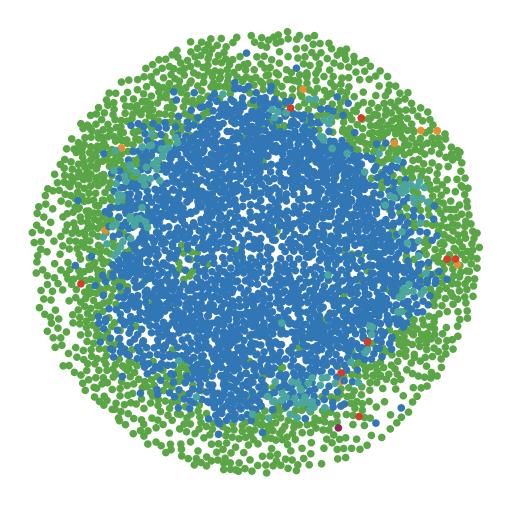

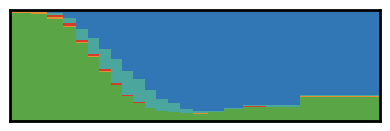

In [21]:
# Show the PREDICTED colony fate calls for all three real perturbation conditions, from
# the Exp20-trained cross-experiment model. Same USE_TRANSFERRED_THRESHOLD toggle as the
# measured version above -- avg_preds is already in each experiment's own native units
# (via run_vib_joint_experiments's to_native_units step), so the "transferred" branch
# additionally forward-aligns it into Exp20's units, reusing align_to_20 from above.
# Reuses perturb_panels, align_to_20, _ThreshWrapper, USE_TRANSFERRED_THRESHOLD,
# thresh_posterior_20 from the measured-colony-fate-calls cell -- run that one first.

display_predicted_fate_calls(avg_preds, 'pred_meas')

TRULI: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_TRULI.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.313
marker_avg | balanced_accuracy = 0.660
TRULI: fate-category performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_fate_TRULI.png
all fates | f1_rand = 0.167
all fates | f1 = 0.162
all fates | balanced_accuracy = 0.254
IWP2: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_IWP2.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.237
marker_avg | balanced_accuracy = 0.674
IWP2: fate-category performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_fate_IWP2.png
all fates | f1_rand = 0.167
all fates | f1 = 0.182
all fates | balanced_accuracy = 0.335
MEKi: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_MEKi.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.360
marker_avg | balanced_accuracy = 0.707
MEKi: fate-category performance -> /Users/idse/dat

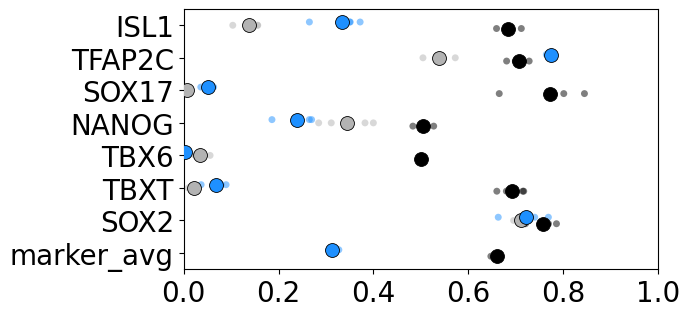

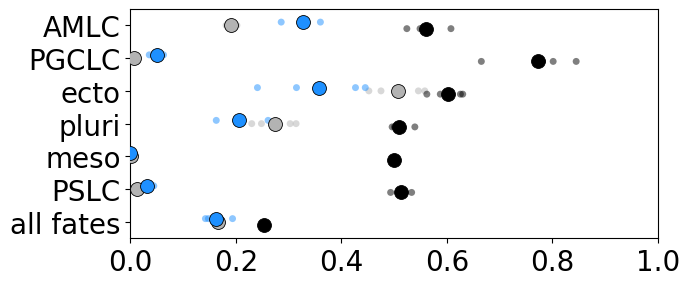

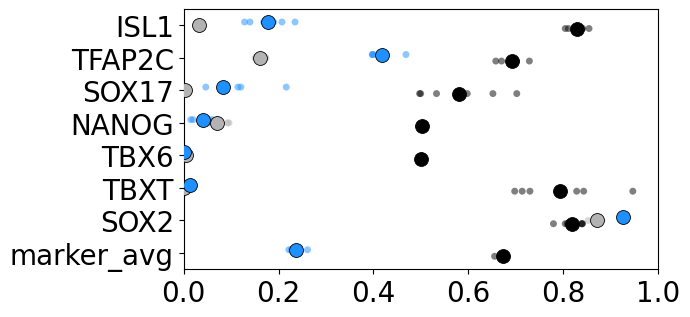

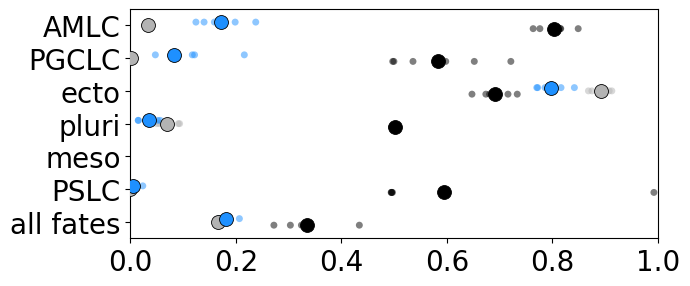

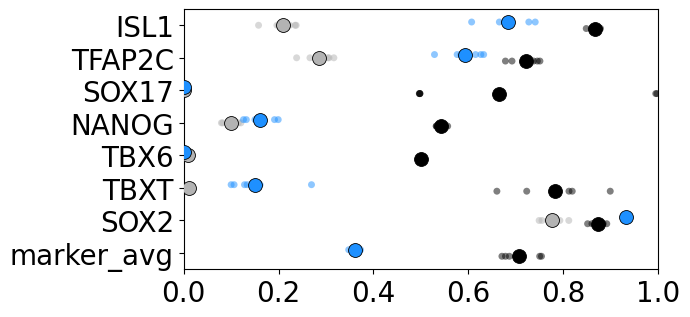

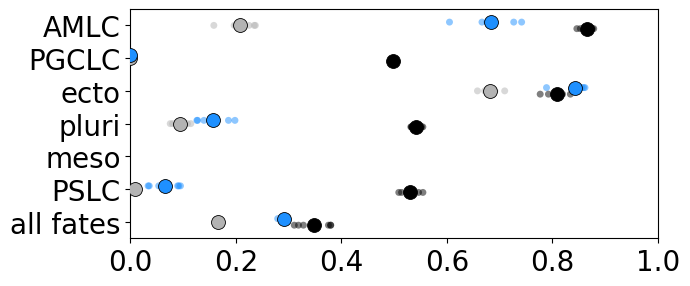

In [53]:
for exp_result, exp_name, cond, colID, label in perturb_panels:
    show_cross_prediction_performance(exp_result, exp_name, cond, avg_preds, label)

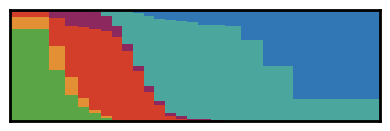

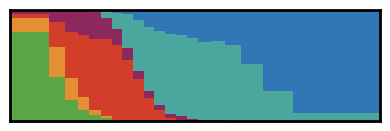

In [74]:
# Z2's OWN B50 (unperturbed control), Z2's own manual threshold -- no alignment needed,
# same experiment. Baseline for comparison against the B50M0p5 histograms above.

data_Z2_B50 = exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50']

IIF.fate_histogram(data_Z2_B50, exp_result_Z2)

# Same Z2 B50 control, transferred into Exp20's units, Exp20's posterior threshold --
# reuses align_Z2_to_20, thresh_posterior_20, and _ThreshWrapper from earlier cells.

data_Z2_B50_in20units = IIF.apply_alignment(data_Z2_B50, align_Z2_to_20, common_gene_names)

IIF.fate_histogram(data_Z2_B50_in20units, _ThreshWrapper(thresh_posterior_20))



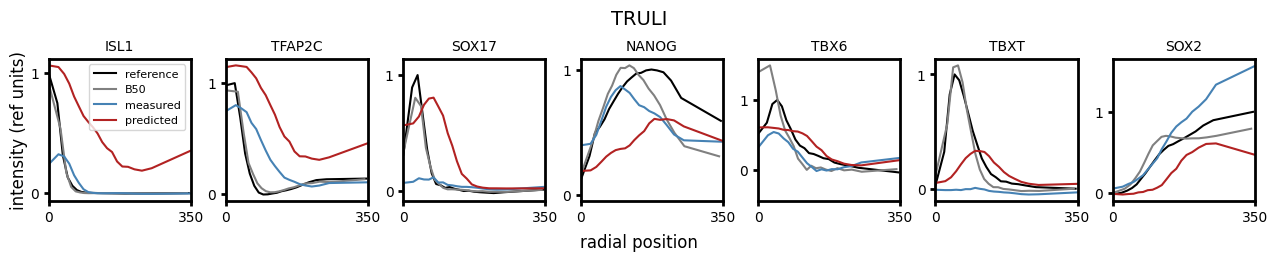

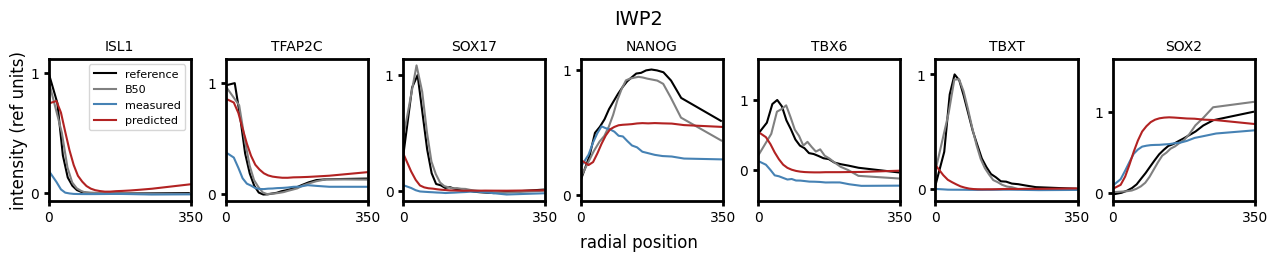

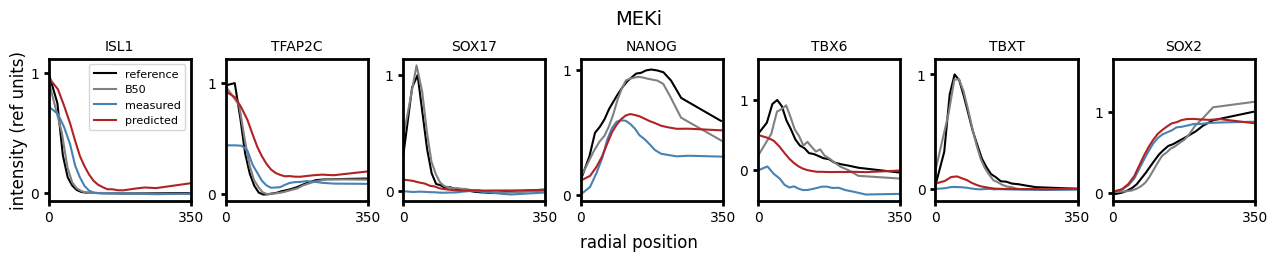

In [ ]:
# RADIAL PROFILES (genes): Exp20 B50 (reference), each condition's own B50 control,
# measured, and control-only-trained predictions -- one figure per perturbation
# condition (TRULI/IWP2/MEKi), via the shared IIF.plot_radial_profiles_comparison.

data_20_B50 = exp_result_20.data[exp_result_20.data['condition'] == 'B50']
figure_configs = [(exp_result.data, exp_name, cond, label) for exp_result, exp_name, cond, colID, label in perturb_panels]

IIF.plot_radial_profiles_comparison(data_20_B50, figure_configs, common_genes, align_to_20, dataDir + '/Fig5', 'radial_profiles_controlonly', pred_variants=[(avg_preds, 'predicted', 'firebrick')])


In [63]:
# JOINT TRAINING VARIANT, looped over all three perturbation conditions: for each, train
# JOINTLY on Exp20's B50 control plus that specific perturbation, then show the resulting
# self-CV prediction for the perturbation condition (leave-one-colony-out, since it was
# part of training -- there's no genuine held-out test here, unlike the control-only path
# above). Same USE_TRANSFERRED_THRESHOLD toggle, reusing align_to_20/common_genes/
# thresh_posterior_20/_ThreshWrapper/perturb_panels from the cells above.

exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

avg_preds_joint_all = {}
for exp_result, exp_name, cond, colID, label in perturb_panels:
    train_configs = [('20', 'B50'), (exp_name, cond)]
    test_configs = []

    avg_preds_joint, _ = IIF.run_vib_joint_experiments(
        exp_results_list=exp_results_list,
        train_configs=train_configs,
        test_configs=test_configs,
        signal_names=[s for s in config.signal_names if s not in ['BCat']], # EXCLUDING BCAT HERE,
        gene_names=common_genes,
        reference_exp='20',
        hyperparam=hyperparam,
        N_run=3,
        out_dir=dataDir + '/VIB_across',
        out_prefix=f'vib_joint_meas_exp20_space_nobcat_{label}',
        recompute=True,
        label=f'exp20+{label} joint training')

    avg_preds_joint_all[(exp_name, cond)] = avg_preds_joint[(exp_name, cond)]


[exp20+TRULI joint training] aligned Z2 -> 20
[exp20+TRULI joint training] aligned X7 -> 20
[exp20+TRULI joint training] Run 0/3
[exp20+TRULI joint training]   fold 0/6
[exp20+TRULI joint training]   fold 1/6
[exp20+TRULI joint training]   fold 2/6
[exp20+TRULI joint training]   fold 3/6
[exp20+TRULI joint training]   fold 4/6
[exp20+TRULI joint training]   fold 5/6
[exp20+TRULI joint training] Elapsed time: 20.2 seconds
[exp20+TRULI joint training] Run 1/3
[exp20+TRULI joint training]   fold 0/6
[exp20+TRULI joint training]   fold 1/6
[exp20+TRULI joint training]   fold 2/6
[exp20+TRULI joint training]   fold 3/6
[exp20+TRULI joint training]   fold 4/6
[exp20+TRULI joint training]   fold 5/6
[exp20+TRULI joint training] Elapsed time: 20.2 seconds
[exp20+TRULI joint training] Run 2/3
[exp20+TRULI joint training]   fold 0/6
[exp20+TRULI joint training]   fold 1/6
[exp20+TRULI joint training]   fold 2/6
[exp20+TRULI joint training]   fold 3/6
[exp20+TRULI joint training]   fold 4/6
[exp2

TRULI: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_TRULI.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.440
marker_avg | balanced_accuracy = 0.679
TRULI: fate-category performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_fate_TRULI.png
all fates | f1_rand = 0.167
all fates | f1 = 0.343
all fates | balanced_accuracy = 0.306
IWP2: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_IWP2.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.290
marker_avg | balanced_accuracy = 0.622
IWP2: fate-category performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_fate_IWP2.png
all fates | f1_rand = 0.167
all fates | f1 = 0.239
all fates | balanced_accuracy = 0.271
MEKi: marker-level performance -> /Users/idse/data_tmp/signaldecoding//Fig5/perfold_marker_MEKi.png
marker_avg | f1_rand = nan
marker_avg | f1 = 0.405
marker_avg | balanced_accuracy = 0.696
MEKi: fate-category performance -> /Users/idse/dat

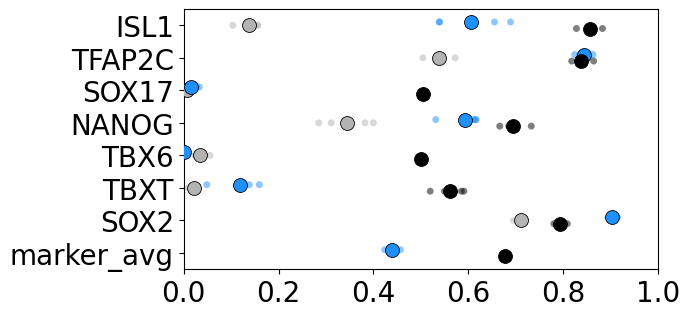

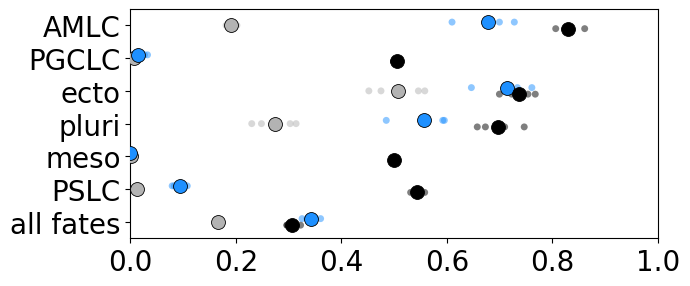

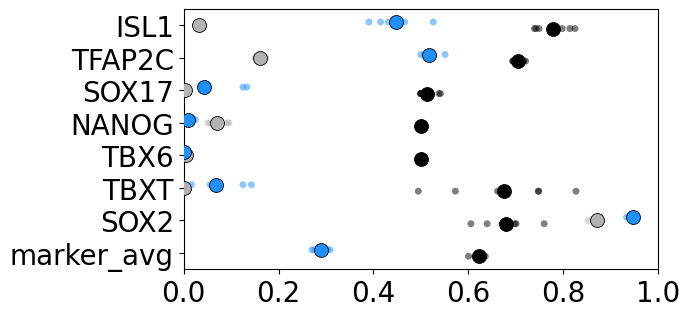

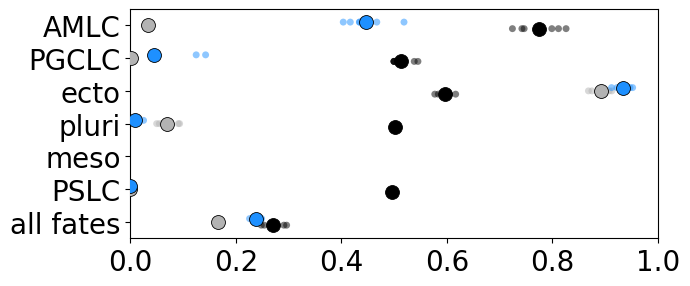

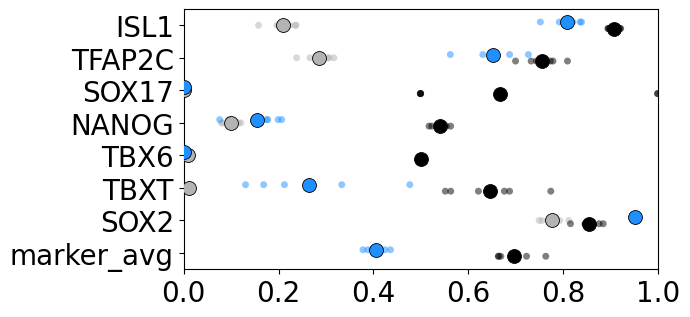

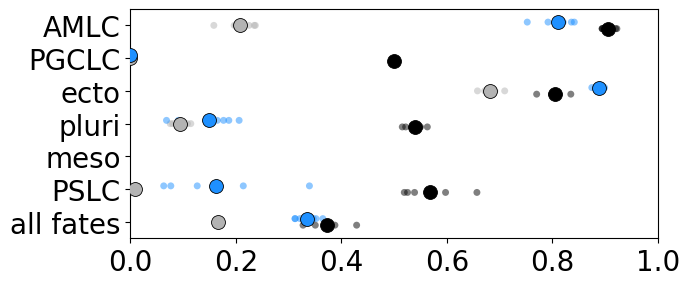

In [56]:
for exp_result, exp_name, cond, colID, label in perturb_panels:
    show_cross_prediction_performance(exp_result, exp_name, cond, avg_preds_joint_all, label)

B50T30, Nbins = 340
B50I5, Nbins = 661
B50M0p5, Nbins = 518


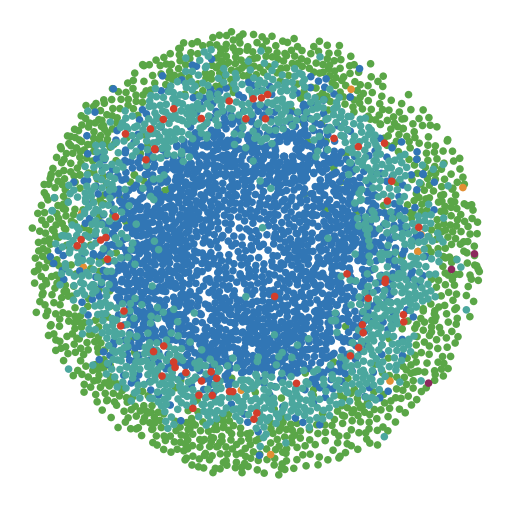

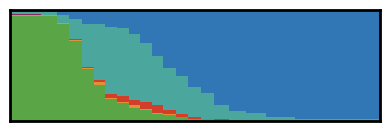

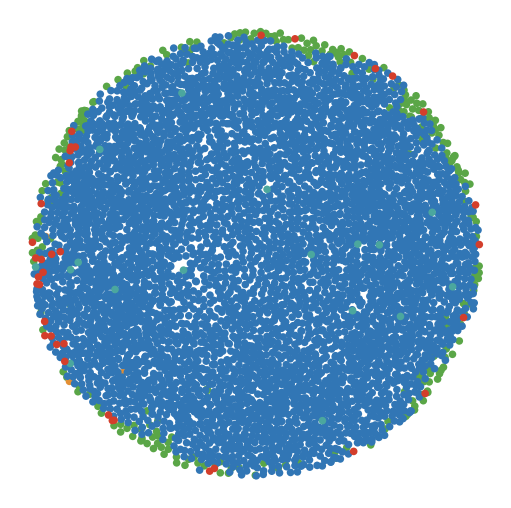

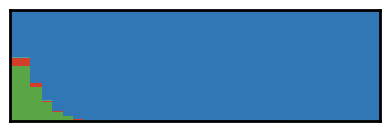

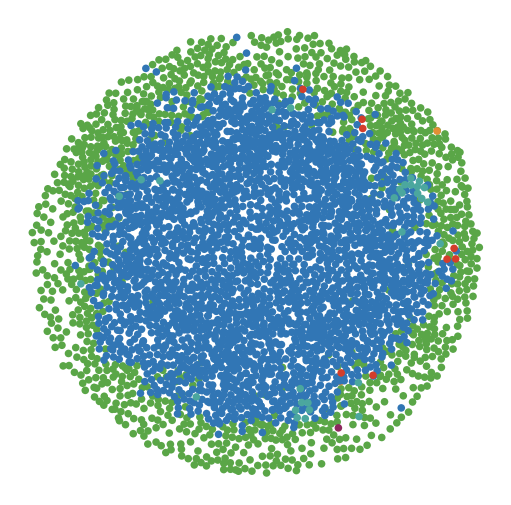

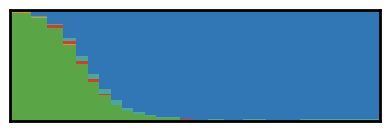

In [ ]:
# Display the joint-trained self-CV predictions, same toggle/loop structure as the
# control-only predicted-fate-calls cell.

display_predicted_fate_calls(avg_preds_joint_all, 'pred_meas_joint')

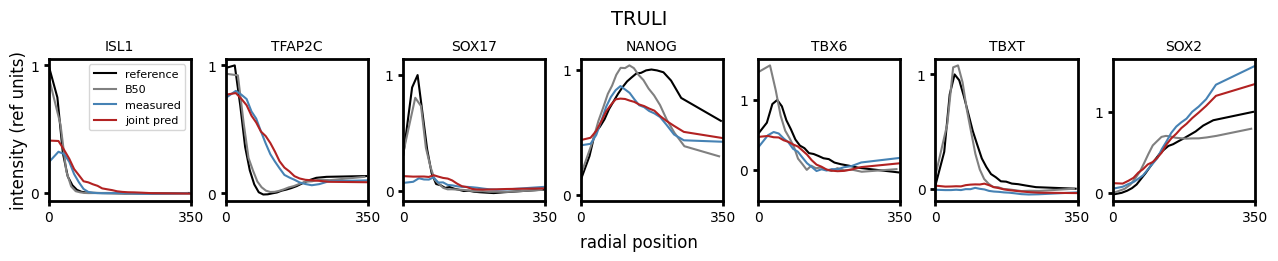

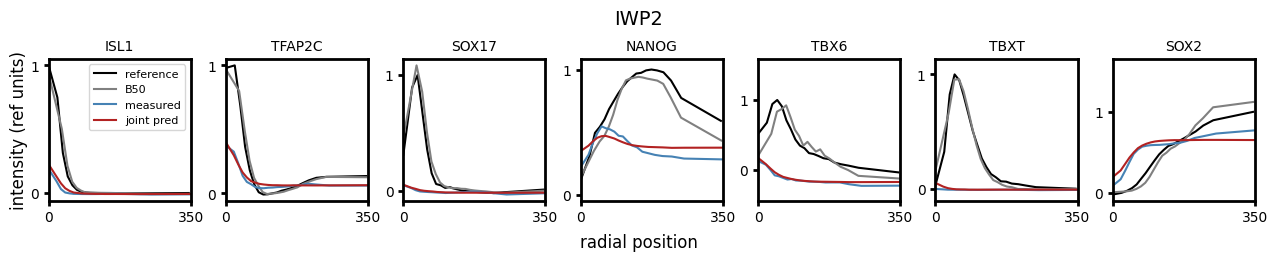

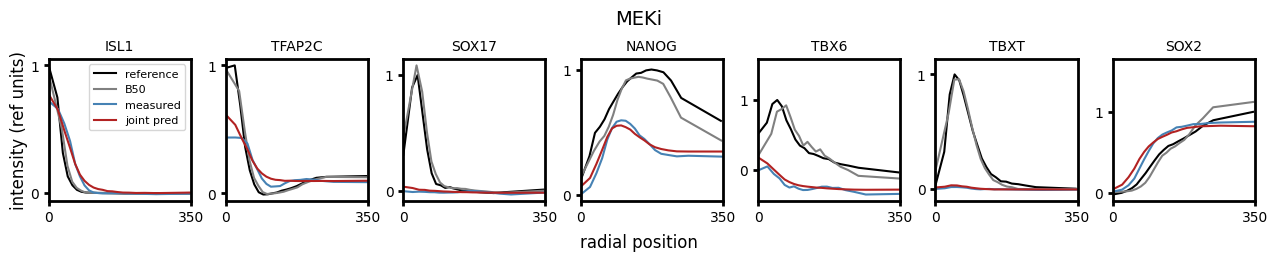

In [78]:
IIF.plot_radial_profiles_comparison(
    data_20_B50, figure_configs, common_genes, align_to_20,
    dataDir + '/Fig5', 'radial_profiles_joint',
    pred_variants=[(avg_preds_joint_all, 'joint pred', 'firebrick')])



In [64]:
# train on B50 from all three experiments:

exp_results_list = {'Z2': exp_result_Z2, 'X7': exp_result_X7, '20': exp_result_20}

train_configs = [('20', 'B50'), ('Z2', 'B50'), ('X7', 'B50')]
test_configs = [('X7', 'B50T30'), ('Z2', 'B50I5'), ('Z2', 'B50M0p5')]

avg_preds_allctrl, _ = IIF.run_vib_joint_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names=[s for s in config.signal_names if s not in ['BCat']],
    gene_names=common_genes,
    reference_exp='20',
    hyperparam=hyperparam,
    N_run=3,
    out_dir=dataDir + '/VIB_across',
    out_prefix='vib_allctrl_exp20_space_nobcat',
    recompute=True,
    label='exp20+Z2+X7 control-only training')


[exp20+Z2+X7 control-only training] aligned Z2 -> 20
[exp20+Z2+X7 control-only training] aligned X7 -> 20
[exp20+Z2+X7 control-only training] Run 0/3
[exp20+Z2+X7 control-only training]   fold 0/6
[exp20+Z2+X7 control-only training]   fold 1/6
[exp20+Z2+X7 control-only training]   fold 2/6
[exp20+Z2+X7 control-only training]   fold 3/6
[exp20+Z2+X7 control-only training]   fold 4/6
[exp20+Z2+X7 control-only training]   fold 5/6
[exp20+Z2+X7 control-only training (joint, run 0)] Run 0/1
[exp20+Z2+X7 control-only training (joint, run 0)]   training on 93469 cells
[exp20+Z2+X7 control-only training (joint, run 0)]   predicting 44213 cells
[exp20+Z2+X7 control-only training (joint, run 0)] Elapsed time: 4.6 seconds
[exp20+Z2+X7 control-only training (joint, run 0)] Run 0/1
[exp20+Z2+X7 control-only training (joint, run 0)]   training on 93469 cells
[exp20+Z2+X7 control-only training (joint, run 0)]   predicting 132522 cells
[exp20+Z2+X7 control-only training (joint, run 0)] Elapsed time: 5

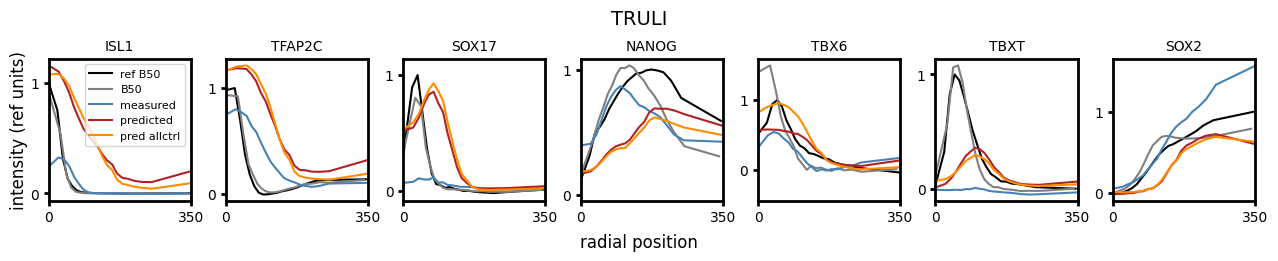

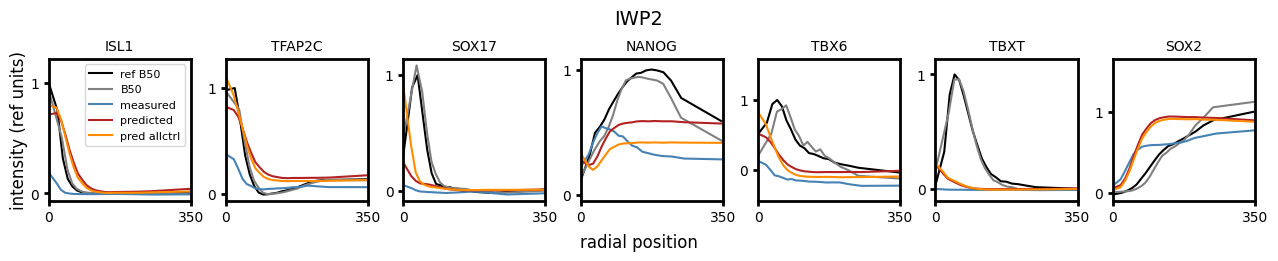

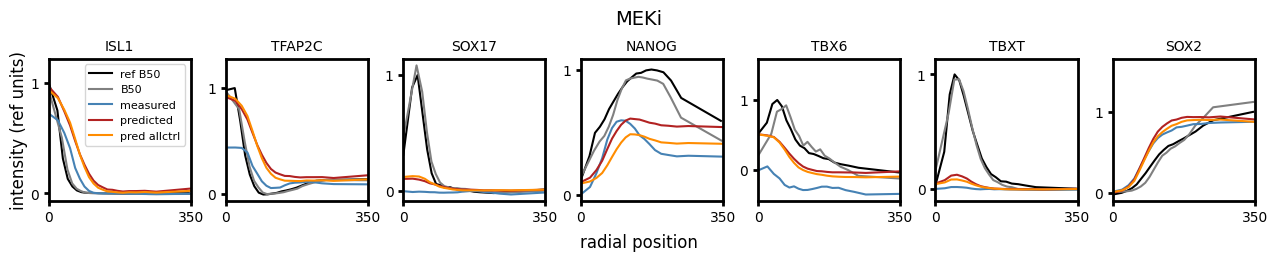

In [59]:
plot_radial_profiles_comparison(
    [(avg_preds, 'predicted', 'firebrick'), (avg_preds_allctrl, 'pred allctrl', 'darkorange')],
    'allctrl')


In [65]:
# train on Exp20 B50 + X7 TRULI, test on the other two

train_configs = [('20', 'B50'), ('X7', 'B50T30')]
test_configs = [('Z2', 'B50I5'), ('Z2', 'B50M0p5')]

avg_preds_truli_joint, _ = IIF.run_vib_joint_experiments(
    exp_results_list=exp_results_list,
    train_configs=train_configs,
    test_configs=test_configs,
    signal_names=[s for s in config.signal_names if s not in ['BCat']],
    gene_names=common_genes,
    reference_exp='20',
    hyperparam=hyperparam,
    N_run=3,
    out_dir=dataDir + '/VIB_across',
    out_prefix='vib_truli_joint_exp20_space_nobcat',
    recompute=True,
    label='exp20+X7-TRULI joint training')

[exp20+X7-TRULI joint training] aligned Z2 -> 20
[exp20+X7-TRULI joint training] aligned X7 -> 20
[exp20+X7-TRULI joint training] Run 0/3
[exp20+X7-TRULI joint training]   fold 0/6
[exp20+X7-TRULI joint training]   fold 1/6
[exp20+X7-TRULI joint training]   fold 2/6
[exp20+X7-TRULI joint training]   fold 3/6
[exp20+X7-TRULI joint training]   fold 4/6
[exp20+X7-TRULI joint training]   fold 5/6
[exp20+X7-TRULI joint training (joint, run 0)] Run 0/1
[exp20+X7-TRULI joint training (joint, run 0)]   training on 47438 cells
[exp20+X7-TRULI joint training (joint, run 0)]   predicting 132522 cells
[exp20+X7-TRULI joint training (joint, run 0)] Elapsed time: 4.8 seconds
[exp20+X7-TRULI joint training] Elapsed time: 25.8 seconds
[exp20+X7-TRULI joint training] Run 1/3
[exp20+X7-TRULI joint training]   fold 0/6
[exp20+X7-TRULI joint training]   fold 1/6
[exp20+X7-TRULI joint training]   fold 2/6
[exp20+X7-TRULI joint training]   fold 3/6
[exp20+X7-TRULI joint training]   fold 4/6
[exp20+X7-TRULI 

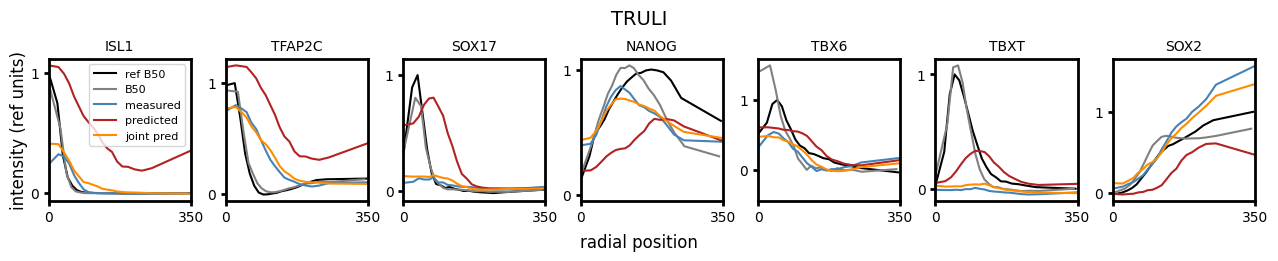

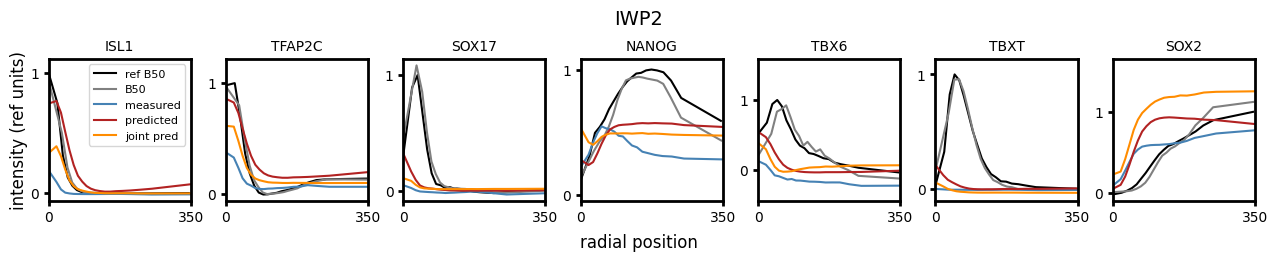

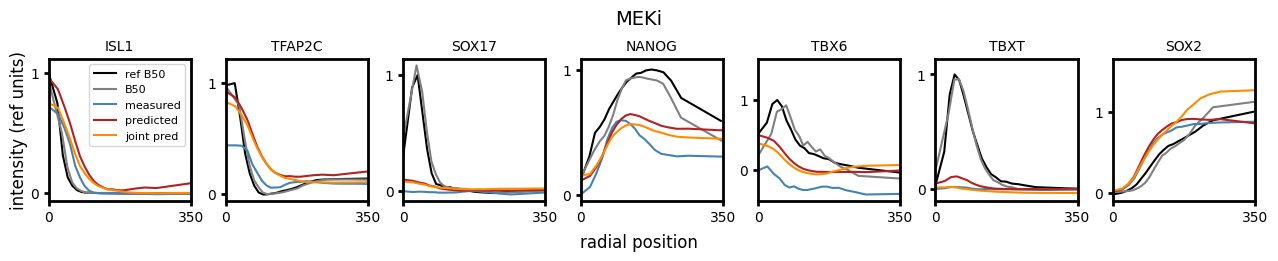

In [47]:
plot_radial_profiles_comparison(
    [(avg_preds, 'predicted', 'firebrick'), (avg_preds_truli_joint, 'joint pred', 'darkorange')],
    'controlonly_and_jointTRULI')

B50T30, Nbins = 340
B50I5, Nbins = 661
B50M0p5, Nbins = 518


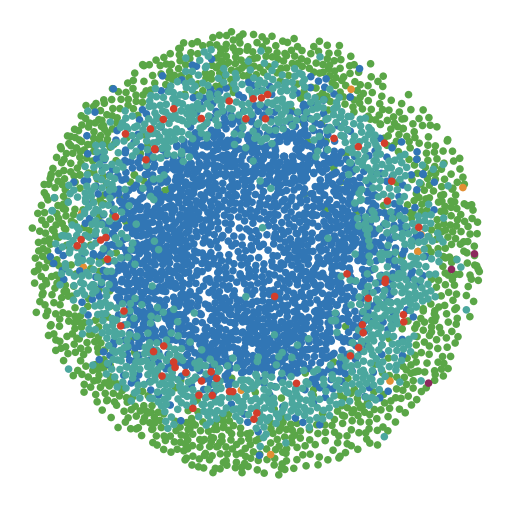

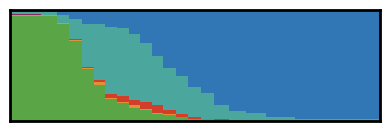

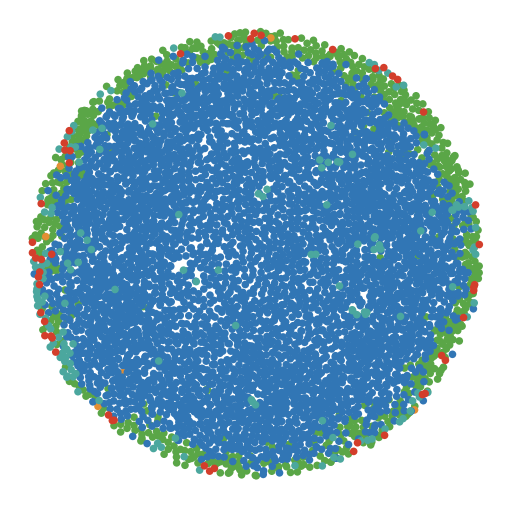

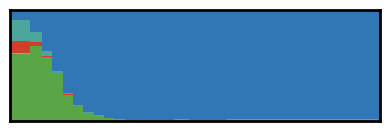

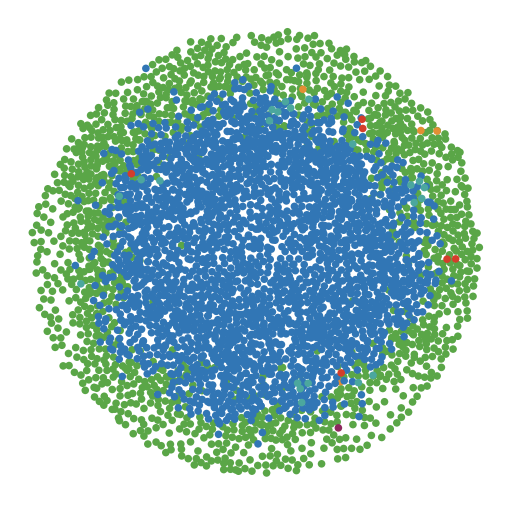

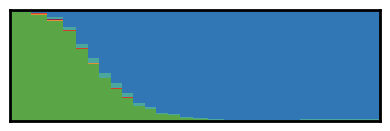

In [66]:
display_predicted_fate_calls(avg_preds_truli_joint, 'pred_meas_truli_joint')

## KNN prediction of perturbations

In [67]:
# Set up for the naive-vs-KNN SYNTHETIC perturbation comparison below: take Exp20's
# own B50 control data, and also compute a KNN-smoothed version of it (so the 'KNN
# perturbation' constructed later isn't just perturbing noisy single-cell values).

# Load Exp20 data for VIB predictions
exp_result    = exp_result_20
meta_pert     = copy.deepcopy(exp_result.meta)
meta_pert.conditions = ['B50']
hyperparam    = {'HIDDEN_DIM': 32, 'N_LAYERS': 2, 'LATENT_DIM': 2}

PERTURB_KWARGS = dict(
    perturbing_sigs=['cytopERK'], perturb_mode='inh',
    percentile=5, k_nn=5, preserve_signals= ['pSMAD1']
)

# Smooth B50 data
data_B50_20  = exp_result.data[exp_result.data['condition'] == 'B50'].copy()
data_smoothed = data_B50_20.copy()
data_smoothed[exp_result.signal_names] = IIF.apply_smoothing(
    data_B50_20[exp_result.signal_names].values, k_val=10, mode='gaussian'
)

In [69]:
# Load one specific pretrained sig2fate VIB model for exp20 
# (run 12, from the hyperparameter sweep) 
# for the latent-space visualizations below.

# Load models from Fig 3
signals = ['pSMAD1', 'ncYAP', 'LEF1', 'BCat', 'ncSMAD23', 'cytopERK']

hyperparam = {'HIDDEN_DIM':32, 'N_LAYERS':2, 'LATENT_DIM': 2}
genes = exp_result_20.gene_names
data = exp_result_20.data

cond = 'B50'
data_cond = data[data['condition']==cond]

feat_train = data_cond[signals] 
tar_train = data_cond[exp_result_20.gene_names]

run = 12
vib = IIF.VIB(feat_train, tar_train, hyperparam)
vib.model = torch.load(
    os.path.join(exp_result_20.exp_dir, f'modelws_12_{len(signals)}D.pth'),
    map_location='cpu', weights_only=False
)
model = vib.model

In [71]:
# NOTE: this 'threshold' is UNRELATED to exp_result.thresh (the fate-marker positivity
# cutoffs used elsewhere). IIF.determine_threshold here finds a percentile cutoff on
# the cytopERK SIGNAL (not a gene), identifying cells that are naturally already low
# in cytopERK -- the basis for SIMULATING a MEK inhibitor treatment (perturb_mode=
# 'inh') without any real drug data.
#   'naive' perturbation  = directly set cytopERK to the threshold value for every cell
#   'KNN' perturbation    = project each cell's full signal vector toward its nearest
#                           neighbors among the naturally-low-cytopERK cells, giving a
#                           smoother, more realistic synthetic perturbation

# Thresholds
threshold= IIF.determine_threshold(
    data_B50_20, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)

threshold_smoothed= IIF.determine_threshold(
    data_smoothed, **{k: PERTURB_KWARGS[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']}
)
# Naive and KNN perturbations
data_naive, data_naive_z    = IIF.create_perturbed_data(
    data_B50_20,  exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=True,
    preserve_signals=PERTURB_KWARGS['preserve_signals']
)
data_knn,   data_knn_z   = IIF.create_perturbed_data(
    data_smoothed, exp_result.signal_names, PERTURB_KWARGS['perturbing_sigs'],
    threshold_smoothed, perturb_mode=PERTURB_KWARGS['perturb_mode'], do_naive=False,
    k_nn=PERTURB_KWARGS['k_nn'], preserve_signals=PERTURB_KWARGS['preserve_signals']
)

col_knn_z, exp_knn_z = IIF.create_experiment(data_knn_z, meta_pert, exp_result.feature_names)

B50, Nbins = 609


  99.0% inside contours
  99.0% inside contours


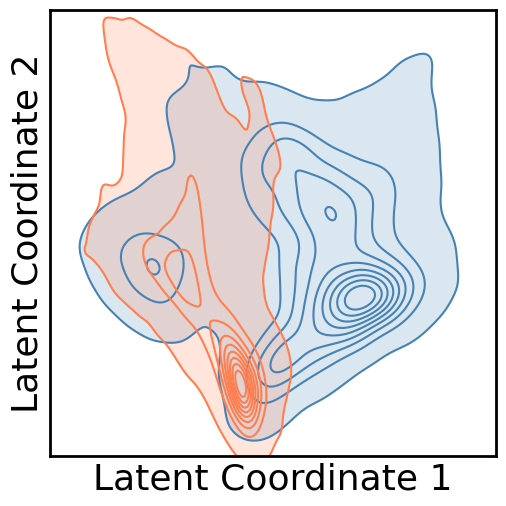

In [74]:
# Load the precomputed fate-map grid (latent space -> predicted fate, plus the L1/L2
# axis limits/normalization) generated in Fig 3. Reused here as a fixed background
# reference for comparing where different conditions land in latent space.

fs = 26
sw = 2  

# load fate map
subdataDir = exp_result_20.exp_dir
L1grid_scaled = np.load(subdataDir + '/fatemap_L1grid_scaled.npy')
L2grid_scaled = np.load(subdataDir + '/fatemap_L2grid_scaled.npy')
fates = list(np.load(subdataDir + '/fatemap_fates.npy'))
L1smin, L1smax, L2smin, L2smax = np.load(subdataDir + '/fatemap_limits.npy')
L1mean, L1std = np.load(subdataDir + '/fatemap_L1mean_L1std.npy')
L2mean = np.load(subdataDir + '/fatemap_L2mean.npy')


do_naive  = True
data_pert = data_naive_z if do_naive else data_knn_z
pert_label = f'naive' if do_naive else f'knn'
filename   = (dataDir+f'/Fig5/LS_fate_{len(exp_result.signal_names)}D_'
              f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
              f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_{pert_label}.png')

data_z = exp_result_20.data_z

# Encode both B50 and perturbed
with torch.no_grad():
    mu_perturb, _ = vib.model.encode(torch.FloatTensor(data_pert[signals].values))
    mu, _ = vib.model.encode(torch.FloatTensor(data_z[data_z['condition'] == 'B50'][signals].values))
        
mu_perturb  = mu_perturb.numpy()
L1_scaled_perturb = (mu_perturb[:, 0] - L1mean) / L1std
L2_scaled_perturb = (mu_perturb[:, 1] - L2mean) / L1std

mu = mu.numpy()
L1_scaled = (mu[:, 0] - L1mean) / L1std
L2_scaled = (mu[:, 1] - L2mean) / L1std

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

# B50 KDE
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='steelblue', linewidths=1.5)


# Perturbed KDE
kde_grid_pert, levels_pert = IIF.kde_on_grid(L1_scaled_perturb, L2_scaled_perturb, L1grid_scaled, L2grid_scaled)
ax.contourf(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', alpha=0.2)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_pert,
           levels=levels_pert, colors='coral', linewidths=1.5)


ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [75]:
# Build the naive/KNN synthetic perturbation datasets for three different drug
# conditions (MEKi, IWP2/WntSeci-inhibiting, TRULI/LATSi-activating), then compute
# per-cell fate-prediction ENTROPY (uncertainty) in latent space for every real,
# naive-predicted, and KNN-predicted condition. Higher entropy = the model is less
# confident/consistent about which fate a cell belongs to.

# Make entropy plots
perturb_configs = {
    'MEKi':  dict(perturbing_sigs=['cytopERK'], perturb_mode='inh', percentile=5,  k_nn=5, preserve_signals=['pSMAD1']),
    'IWP2':  dict(perturbing_sigs=['LEF1'],     perturb_mode='inh', percentile=0.1, k_nn=5, preserve_signals=['pSMAD1']),
    'TRULI': dict(perturbing_sigs=['ncYAP'],    perturb_mode='act',  percentile=5,   k_nn=5, preserve_signals=None),
}

# Measured conditions
meas_configs = [
    (exp_result_20, 'B50',     'B50'),
    (exp_result_Z2, 'B50M0p5', 'Z2 MEKi'),
    (exp_result_Z2, 'B50I5',   'Z2 IWP2'),
    (exp_result_X7, 'B50T30',  'X7 TRULI'),]

naive_data, naive_data_z, knn_data, knn_data_z = {}, {}, {}, {}

for label, kwargs in perturb_configs.items():
    threshold = IIF.determine_threshold(data_B50_20, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    threshold_smoothed = IIF.determine_threshold(data_smoothed, **{k: kwargs[k] for k in ['perturbing_sigs', 'perturb_mode', 'percentile']})
    
    naive_data[label], naive_data_z[label] = IIF.create_perturbed_data(
        data_B50_20, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold,
        perturb_mode=kwargs['perturb_mode'], do_naive=True,
        preserve_signals=kwargs['preserve_signals']
    )
    knn_data[label], knn_data_z[label] = IIF.create_perturbed_data(
        data_smoothed, exp_result_20.signal_names,
        kwargs['perturbing_sigs'], threshold_smoothed,
        perturb_mode=kwargs['perturb_mode'], do_naive=False,
        k_nn=kwargs['k_nn'], preserve_signals=kwargs['preserve_signals']
    )


# All datasets to process: (raw_data, z_data, label)
entropy_datasets = (
    [(exp_res.data[exp_res.data['condition'] == cond],
      exp_res.data_z[exp_res.data_z['condition'] == cond], label)
     for exp_res, cond, label in meas_configs] +
    [(naive_data[k],  naive_data_z[k],  f'{label} (naive)') for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])] +
    [(knn_data[k],    knn_data_z[k],    f'{label} (knn)')   for k, (_, _, label) in zip(perturb_configs, meas_configs[1:])]
)

latent_entropy_results = {}

for _, data_cond_z, label in entropy_datasets:
    per_cell, mu_np = IIF.compute_latent_position_entropy(
        vib, data_cond_z,
        signals,
        exp_result_20.gene_names,
        exp_result_20.thresh,
        n_samples=1000
    )

    latent_entropy_results[label] = {
        'per_cell': per_cell,
        'L1':       (mu_np[:, 0] - L1mean) / L1std,
        'L2':       (mu_np[:, 1] - L2mean) / L1std,
        'mean':     per_cell.mean()
    }

KeyboardInterrupt: 

B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
B50, Nbins = 717
B50I5, Nbins = 661
B50SB10, Nbins = 755
B50M0p5, Nbins = 518
  99.0% inside contours
  99.0% inside contours


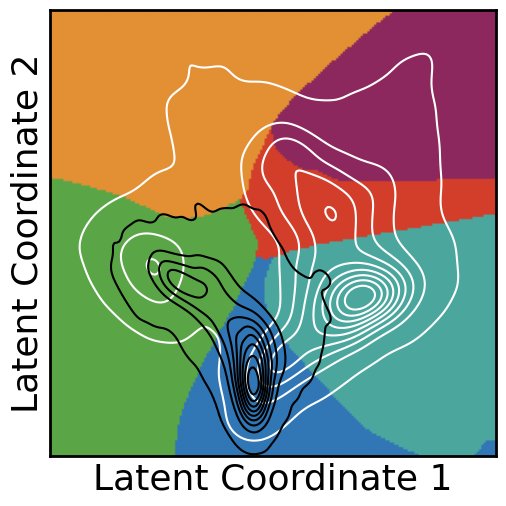

In [ ]:
# Build the fate-colored background image for the latent-space plots, and encode one
# specific measured perturbation condition (Z2, B50M0p5) into that same latent space,
# for direct visual comparison against the B50 control cloud.

# precompute rgb image once
rgb_image = np.zeros((200, 200, 3))
for i, fate in enumerate(fates):
    color = IIF.colmap_fates[fate]
    rgb_image[i // 200, i % 200] = mcolors.to_rgb(color)


# Encode measured condition
exp_result_meas = IIF.ExperimentResults('Z2', config)
cond = 'B50M0p5'

data_B50_meas = exp_result_meas.data[exp_result_meas.data['condition'] == 'B50'].copy()
data_cond = exp_result_meas.data[exp_result_meas.data['condition'] == cond].copy()
data_cond_z  = exp_result_meas.data_z[exp_result_meas.data_z['condition'] == cond].copy()
mu_meas, _ = vib.model.encode(
    torch.FloatTensor(data_cond_z[signals].values)
)
mu_meas = mu_meas.detach().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std

filename = (dataDir + f'/Fig5/LS_fate_{len(exp_result.signal_names)}D_'
            f'{PERTURB_KWARGS["perturbing_sigs"][0]}_'
            f'{PERTURB_KWARGS["perturb_mode"]}_ctrl_vs_meas.png')

# Plot
fs = 26
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

# B50 KDE (white)
kde_grid_b50, levels_b50 = IIF.kde_on_grid(L1_scaled, L2_scaled, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,
           levels=levels_b50, colors='white', linewidths=1.5)

# Measured KDE (black)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
           levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlim(L1smin, L1smax)
ax.set_ylim(L2smin, L2smax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig(filename, dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# Smoothly interpolate/extrapolate the per-cell B50 entropy values onto a regular
# latent-space grid, for the background entropy map used in the plots below.

from scipy.interpolate import RBFInterpolator

# Extrapolate B50 latent entropy
res      = latent_entropy_results['B50']
points   = np.stack([res['L1'], res['L2']], axis=1)
entropy_vals = res['per_cell'].values

# Grid matching latent space
grid_size   = 200
l1_grid     = np.linspace(L1smin, L1smax, grid_size)
l2_grid     = np.linspace(L2smin, L2smax, grid_size)
L1g, L2g    = np.meshgrid(l1_grid, l2_grid)
grid_points = np.stack([L1g.ravel(), L2g.ravel()], axis=1)

# RBF interpolation/extrapolation
rbf          = RBFInterpolator(points, entropy_vals,
                               kernel='thin_plate_spline', smoothing=0.005)
entropy_grid = rbf(grid_points).reshape(grid_size, grid_size)
entropy_grid = np.clip(entropy_grid, 0, np.log2(len(IIF.colmap_fates)))

In [ ]:
# Custom diverging colormap (clipped RdBu_r) for the entropy heatmaps below.

import matplotlib.colors as mcolors

# Clip RdBu_r
frac_start = 0.2 / 2.2  # = vmin_magnitude / total_range

cmap_clipped = mcolors.LinearSegmentedColormap.from_list(
    'RdBu_r_clipped',
    plt.colormaps['RdBu_r'](np.linspace(frac_start, 1.0, 256))
)

  99.0% inside contours


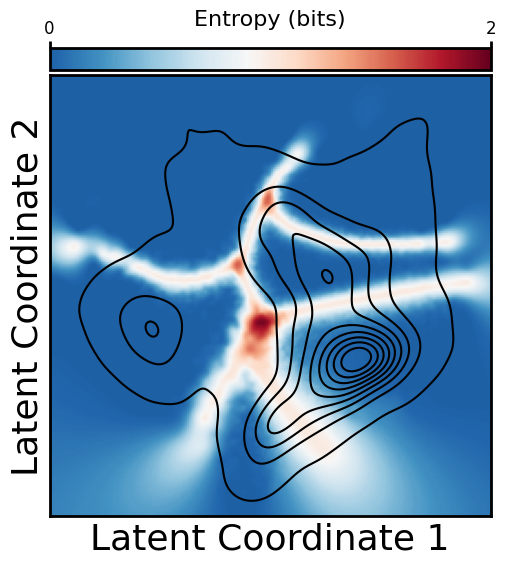

  99.0% inside contours


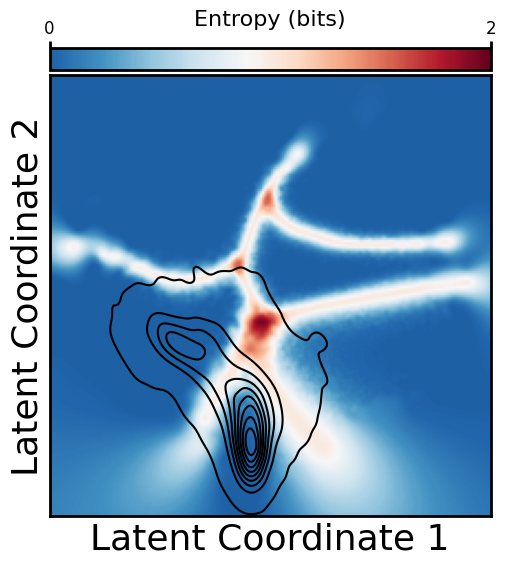

  99.0% inside contours


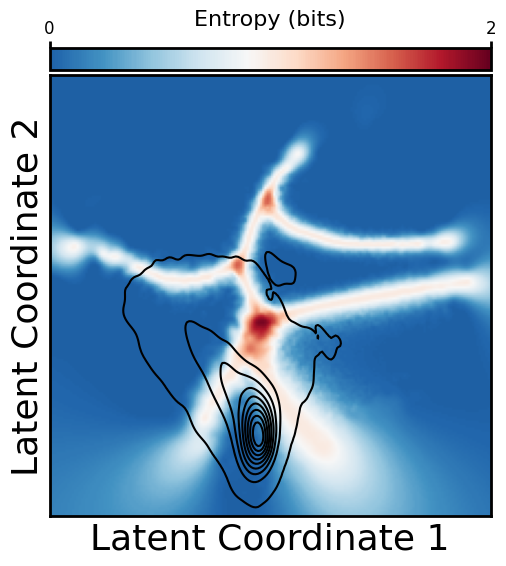

  99.0% inside contours


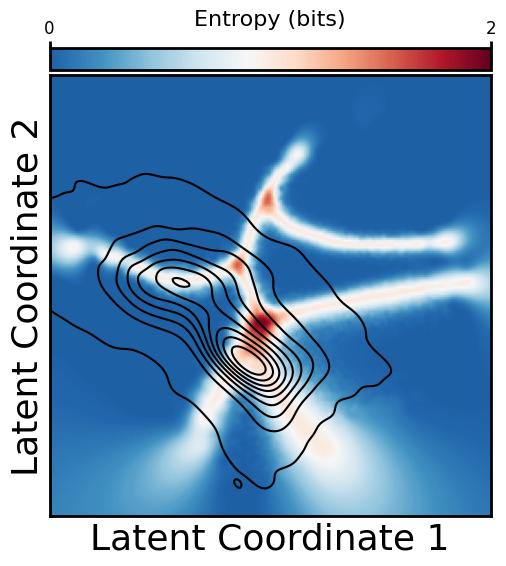

In [ ]:
# For each real experimental condition, overlay its measured latent-space density
# (black contour) on top of the interpolated B50 entropy background -- shows whether
# perturbed/measured cells land in regions the model is more or less confident about.

from mpl_toolkits.axes_grid1 import make_axes_locatable

for exp_res, cond, label in meas_configs:
    
    # Encode measured condition
    data_cond_z       = exp_res.data_z[exp_res.data_z['condition'] == cond]
    mu_meas, _        = vib.model.encode(
        torch.FloatTensor(data_cond_z[signals].values)
    )
    mu_meas           = mu_meas.detach().numpy()
    L1_scaled_meas    = (mu_meas[:, 0] - L1mean) / L1std
    L2_scaled_meas    = (mu_meas[:, 1] - L2mean) / L1std

    # Plot
    fig, ax = plt.subplots(figsize=(5, 6))
    im      = ax.imshow(entropy_grid, origin='lower',
                        extent=[L1smin, L1smax, L2smin, L2smax],
                        cmap=cmap_clipped, vmin=0, vmax=2, aspect='auto', zorder=1)

    # Colorbar on top
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('top', size='5%', pad=0.05)
    cbar    = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('Entropy (bits)', fontsize=16, labelpad=-4)
    cbar.ax.tick_params(labelsize=12, length=5, width=2, pad=2)
    cbar.set_ticks([0, 2])
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(sw)

    # Measured KDE
    kde_grid_meas, levels_meas = IIF.kde_on_grid(
        L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled
    )
    ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas,
               levels=levels_meas, colors='black', linewidths=1.5)

    ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
    ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(L1smin, L1smax)
    ax.set_ylim(L2smin, L2smax)
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_linewidth(sw)

    plt.tight_layout(pad=0.5)
    plt.savefig(
        os.path.join(dataDir + f'/Fig5/LS_entropy_kde_{label.replace(" ", "_")}.png'),
        dpi=150, bbox_inches='tight', pad_inches=0.1
    )
    plt.show()
    plt.close()

In [ ]:
# Feed the naively-perturbed and KNN-perturbed SYNTHETIC signal data through the
# (already-trained, loaded-from-disk) VIB model trained on Exp20 B50, predicting what
# fate-marker expression -- and therefore what fates -- a MEK inhibitor treatment
# would be predicted to produce, without any real inhibitor experiment.

# Make VIB predictions based on naive and projected signaling
_, avg_pred_naive, predictions_naive = IIF.run_vib_predictions(
    exp_result.exp_dir, data_B50_20, data_naive,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)
_, avg_pred_knn, predictions_knn = IIF.run_vib_predictions(
    exp_result.exp_dir, data_smoothed, data_knn,
    exp_result.signal_names, exp_result.gene_names, hyperparam, N_run=3
)

col_naive_pred, _ = IIF.create_experiment(avg_pred_naive, meta_pert, exp_result.feature_names)
col_knn_pred,   _ = IIF.create_experiment(avg_pred_knn,   meta_pert, exp_result.feature_names)

load VIB
load VIB
load VIB
load VIB
load VIB
load VIB
B50, Nbins = 609
B50, Nbins = 609


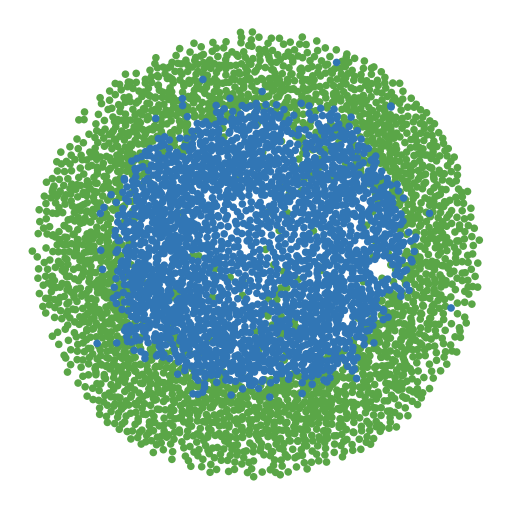

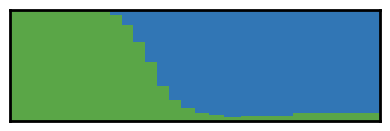

In [ ]:
# Compare predicted fate maps for the naive vs. KNN synthetic-perturbation predictions
# from the previous cell.

# Plot colony scatter + fate histogram
do_naive=False

lim = 353
col_id = 2
ms = 30

fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
if do_naive:
    col_naive_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = dataDir + f'/Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    data_for_hist = avg_pred_naive
    hist_filename = dataDir + f'/Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_naive.png'
    #mu_perturb = encode_data(vib_choice, data_naive_z, exp_result.signal_names)
else:
    col_knn_pred[col_id].scatter_fates(ms=ms, ax=ax, legend=False, thresh=exp_result_20.thresh)
    filename = dataDir + f'Fig5/colony_scatter_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    data_for_hist = avg_pred_knn
    hist_filename = dataDir + f'Fig5/hist_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_pred_knn.png'
    #mu_perturb = encode_data(vib_choice, data_knn_z, exp_result.signal_names)
    

plt.savefig(filename) 

IIF.fate_histogram(data_for_hist, exp_result_20)
plt.savefig(hist_filename)

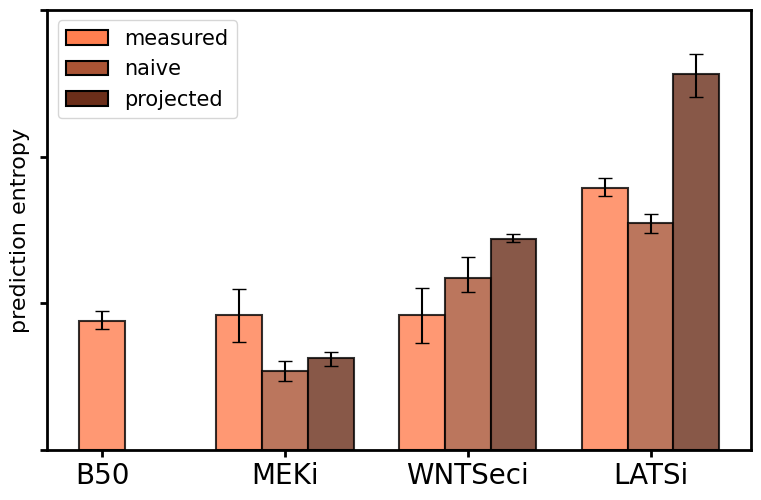

In [ ]:
# Summarize mean per-cell entropy across all conditions (real, naive-predicted,
# KNN-predicted) in one comparison plot.

# Plot mean entropy for each predictions
condition_data_dict = {
    'B50':              exp_result_20.data[exp_result_20.data['condition'] == 'B50'],
    'Z2 MEKi':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50M0p5'],
    'Z2 IWP2':          exp_result_Z2.data[exp_result_Z2.data['condition'] == 'B50I5'],
    'X7 TRULI':         exp_result_X7.data[exp_result_X7.data['condition'] == 'B50T30'],
    'Z2 MEKi (naive)':  naive_data['MEKi'],
    'Z2 IWP2 (naive)':  naive_data['IWP2'],
    'X7 TRULI (naive)': naive_data['TRULI'],
    'Z2 MEKi (knn)':    knn_data['MEKi'],
    'Z2 IWP2 (knn)':    knn_data['IWP2'],
    'X7 TRULI (knn)':   knn_data['TRULI'],
}

fig, ax = IIF.plot_latent_entropy_comparison(
    latent_entropy_results=latent_entropy_results,
    condition_data_dict=condition_data_dict,
    figsize=(8, 5),
    use_ci=True
)

for spine in ax.spines.values():
    spine.set_linewidth(sw)

ax.tick_params(axis='x', labelsize=fs_ticks, width=sw, length=5)
ax.tick_params(axis='y', labelsize=fs_ticks, width=sw, length=5)
ax.set_yticks([0, 0.3, 0.6, 0.9])
ax.set_yticklabels([]) 

plt.savefig(dataDir + '/Fig5/entropy_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

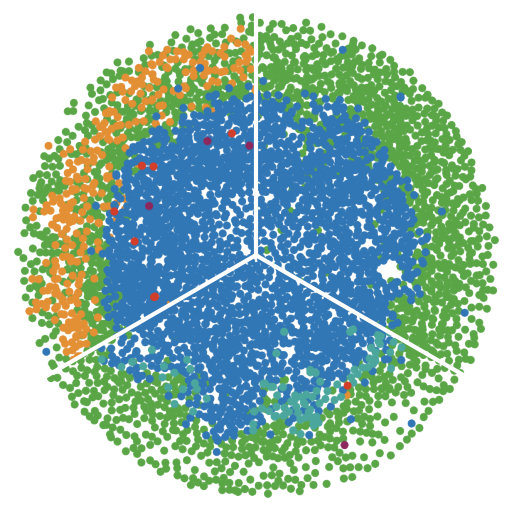

In [ ]:
# Side-by-side fate-pie comparison of naive-predicted, real measured, and KNN-predicted
# colonies for the same perturbation.

fig, ax = IIF.plot_colony_pie_triplet(
    colony_list=[col_naive_pred[2], col_objects[('Z2', 'B50M0p5')][19], col_knn_pred[2]],
    exp_result_list=[exp_result_20, exp_result_Z2, exp_result_20],
    labels=['', '', ''],
    ms=30,           # matches plot_colony_and_histogram default
    start_angle=90,
    boundary_color='white',
    boundary_lw=3,
    #lim = 375
)

plt.savefig(dataDir+f'Fig5/three_way_colony_plot_{PERTURB_KWARGS['perturbing_sigs'][0]}_{PERTURB_KWARGS['perturb_mode']}_naive_knn_meas.png') 

  99.0% inside contours
  99.0% inside contours


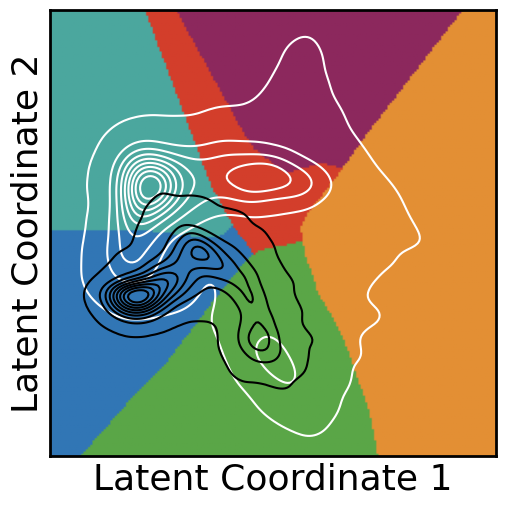

In [ ]:
# Build a fresh fate-map background specific to the jointly-trained model's own latent
# space (which differs from the Fig-3 model's latent space loaded earlier), then
# overlay both the B50 control and the real measured perturbation for a final
# side-by-side comparison figure.

# Encode B50 in joint map
vib_joint_choice = vib_joint[0][0]
model     = vib_joint_choice.model


data_z_B50 = exp_result_20.data_z[exp_result_20.data_z['condition'] == 'B50']
X          = torch.FloatTensor(data_z_B50[signals].values).to(device)

model.eval()
with torch.no_grad():
    mu, _ = model.encode(X)

L1, L2         = mu[:, 0].cpu().numpy(), mu[:, 1].cpu().numpy()
L1mean, L1std  = L1.mean(), L1.std()
L2mean         = L2.mean()
L1_scaled      = (L1 - L1mean) / L1std
L2_scaled      = (L2 - L2mean) / L1std

# Axis limits
marg = 0.5
xlim      = (np.percentile(L1_scaled, 0.1) - marg, np.percentile(L1_scaled, 99.9) + marg)
ylim      = (np.percentile(L2_scaled, 0.1) - marg, np.percentile(L2_scaled, 99.9) + marg)
max_range = max(xlim[1] - xlim[0], ylim[1] - ylim[0])
x_center  = (xlim[0] + xlim[1]) / 2
y_center  = (ylim[0] + ylim[1]) / 2

L1smin, L1smax, L2smin, L2smax = (x_center - max_range/2, x_center + max_range/2,
                                y_center - max_range/2, y_center + max_range/2)

# Grid
L1grid_scaled, L2grid_scaled = np.meshgrid(
    np.linspace(L1smin, L1smax, 200),
    np.linspace(L2smin, L2smax, 200)
)
L1grid_raw = L1grid_scaled * L1std + L1mean
L2grid_raw = L2grid_scaled * L1std + L2mean

# Fate map
with torch.no_grad():
    Y_z   = model.decode(torch.FloatTensor(
        np.stack([L1grid_raw.ravel(), L2grid_raw.ravel()], axis=1)
    ).to(device)).cpu().numpy()

Y_fate      = pd.DataFrame(scalers['20']['Y'].inverse_transform(Y_z), columns=common_gene_names)
fates, _    = IIF.return_fates(Y_fate, thresh=exp_result_20.thresh)
fate_colors = np.array([mcolors.to_rgb(IIF.colmap_fates[f]) for f in fates])
rgb_image   = fate_colors.reshape(200, 200, 3)


# Encode measured perturbation
data_meas_z       = exp_result_Z2.data_z[exp_result_Z2.data_z['condition'] == 'B50M0p5']
X_meas            = torch.FloatTensor(data_meas_z[signals].values).to(device)

with torch.no_grad():
    mu_meas, _ = model.encode(X_meas)
mu_meas = mu_meas.cpu().numpy()

L1_scaled_meas = (mu_meas[:, 0] - L1mean) / L1std
L2_scaled_meas = (mu_meas[:, 1] - L2mean) / L1std


# Plot

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_image, origin='lower', extent=[L1smin, L1smax, L2smin, L2smax])

kde_grid_b50,  levels_b50  = IIF.kde_on_grid(L1_scaled,      L2_scaled,      L1grid_scaled, L2grid_scaled)
kde_grid_meas, levels_meas = IIF.kde_on_grid(L1_scaled_meas, L2_scaled_meas, L1grid_scaled, L2grid_scaled)

ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_b50,  levels=levels_b50,  colors='white', linewidths=1.5)
ax.contour(L1grid_scaled, L2grid_scaled, kde_grid_meas, levels=levels_meas, colors='black', linewidths=1.5)

ax.set_xlabel('Latent Coordinate 1', fontsize=fs)
ax.set_ylabel('Latent Coordinate 2', fontsize=fs)
ax.set_xticks([]);  ax.set_yticks([])
ax.set_xlim(L1smin, L1smax);  ax.set_ylim(L2smin, L2smax)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_linewidth(sw)

plt.tight_layout(pad=0.5)
plt.savefig('LS_fate_6D_LEF1_inh_ctrl_vs_meas_joint.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()